---
title: "Chapter 4, Part 4: ARIMA Models"
subtitle: "Machine Learning"
date: "March 2026"
date-format: "MMMM YYYY"
author: 
  - F.San Segundo & N.Rodríguez
bibliography: ../exclude/mlmiin.bib
execute:
  echo: true
code-overflow: wrap
format: 
  html: 
    toc: true
    code-tools: true
    code-fold: show
    code-summary: "Hide the code"
    embed-resources: true
---

---

::: {.callout-warning icon=false}

##### Setting the working directory

We begin by using cd to make sure we are in the right folder.

:::

In [1]:
%cd /wd/4_4_Arima

/wd/4_4_Arima


---

# Session Setup

::: {.callout-note  icon=false}

### Install additional libraries

We need to install some libraries from the [Nixtlaverse](https://nixtlaverse.nixtla.io/)

:::



In [2]:
import subprocess

def pip_install(package):
    result = subprocess.run(
        ["pip", "install", package],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        print(f"Error installing {package}: {result.stderr}")
    else:
        print(f"Successfully installed {package}")

pip_install("fpppy")
pip_install("tsfeatures")
pip_install("pyreadr")

::: {.callout-note  icon=false}

### Libraries

Let us also load the libraries we will use.

:::



In [3]:
# 1. System and Environment Setup
import os
import sys
import warnings
import random
import datetime
from tqdm import tqdm

# Set environment variables and ignore specific warnings
os.environ["NIXTLA_ID_AS_COL"] = "true"
warnings.filterwarnings(
    "ignore", 
    category=UserWarning, 
    message=".*FigureCanvasAgg is non-interactive.*"
)

# 2. Core Data Science Stack
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs


# 3. Time Series & Machine Learning
import pmdarima as pmd
import yfinance as yf
import rdatasets
import pyreadr

# 4. Custom Utilities
from fc_4_3_utils.utils import *
from fpppy.utils import plot_series as plot_series_fpp
from utilsforecast.plotting import plot_series as plot_series_utils

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mape
from statsforecast import StatsForecast

from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
)

from statsforecast.models import MSTL



# 5. Global Reproducibility & Display Settings
np.random.seed(1)
random.seed(1)
np.set_printoptions(suppress=True)

pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)

# 6. Plotting Configuration
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler

# Jupyter Magic
%matplotlib inline
# %config InlineBackend.figure_format = 'png' # High-res plots

# Style and Aesthetics
plt.style.use("ggplot")
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

# Custom color cycle (Example: monochromatic black as per your original)
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])

In [4]:
from typing import Optional

from IPython.display import Image
from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs
from statsforecast.models import ARIMA, AutoARIMA, AutoETS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from utilsforecast.losses import rmse, mae, smape

In [5]:
import warnings
import os

# Ignore all warnings
warnings.filterwarnings("ignore")

# Specifically target Scikit-Learn/FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Some environments also require setting an environment variable
os.environ['PYTHONWARNINGS'] = 'ignore'

---

In [6]:
### Load necessary modules -------------------------------

# %config InlineBackend.figure_format = 'png' # ‘png’, ‘retina’, ‘jpeg’, ‘svg’, ‘pdf’

import numpy as np 
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('notebook')


%matplotlib inline

# Machine Learning general libraries

from sklearn.metrics import mean_squared_error, mean_absolute_error

# statsmodels
import statsmodels.stats.api as sms
import statsmodels.api as sm
from statsmodels.formula.api import ols


# Time Series related imports

import datetime

from sklearn.model_selection import TimeSeriesSplit

import statsmodels.api as sm

# pmdarima
import pmdarima as pmd

import statsmodels.tsa as tsa
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA as smARIMA

# datasets
import rdatasets
import yfinance as yf

# tqdm 
from tqdm import tqdm

from fc_4_3_utils.utils import *



In [7]:
from typing import Optional

from IPython.display import Image
from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs
from statsforecast.models import ARIMA, AutoARIMA, AutoETS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from utilsforecast.losses import rmse, mae, smape

---

#  Autoregressive (AR) Processes

::: {.callout-note icon=false}

#### Introduction

In the following sections we will gradually introduce the ARIMA model family, which is the most important of the classical time series forecasting models. The ARIMA models combine the ideas of autoregressive (AR) processes, moving average (MA) processes, and differencing (the I is for integration, as the opposite of differencing) to create a powerful model that can capture a wide range of time series dynamics. We will first see what AR (autoregressive) and MA (moving average) processes are, before introducing the ARIMA models.

Later we will extend these methods to seasonal ARIMA models, usually called SARIMA models,  which will enable us to capture the seasonal dynamics of the time series.

:::

::: {.callout-note icon=false}

#### AR Process Definition in the Non Seasonal (or Regular) Case

A stochastic process $(Y_t)$ is called **autoregressive** if it satisfies the equation:

$$y_{t} = \phi_{1}y_{t-1} + \phi_{2}y_{t-2} + \dots + \phi_{p}y_{t-p} + \varepsilon_{t},$$

where:
+ $(\varepsilon_{t})$ is **gaussian white noise.** 
+ $\phi_1, \ldots, \phi_{p}$ are constants, called the **coefficients** of the process. 
+ The number $p$ is the **order** of the process, which is then called an **$AR(p)$ process**.

Any time series which is a realization of an autoregressive process is called an **autoregressive time series**. 

An autoregressive process can be considered as anlogous to a multiple linear regression model. But here the prediction of $y_t$ uses recent lags of the time series as input variables. We regress the time series onto its recent past, and that is why we call it **autoregressive**.

:::

::: {.callout-note icon=false}

#### Backshift Operator and Characteristic Polynomial

Using the **backshift operator** $B(y_t) = y_{t - 1}$ we can write the autoregressive process as:

$$\Phi(B) y_t = (1-\phi_1B - \cdots - \phi_p B^p)y_{t} = \varepsilon_{t}$$

where 
$$\Phi(B) = (1-\phi_1B - \cdots - \phi_p B^p)$$
is the **characteristic polynomial** of the process. 

:::


::: {.callout-note icon=false}

#### $AR(1)$ and $AR(2)$ Processes

We are particularly interested in the lower order processes. A process of type $AR(1)$ is:
$$y_{t} = \phi_{1}y_{t-1}  + \varepsilon_{t},$$
or in characteristic polynomial form:
$$(1 - \phi_{1} B)y_{t} = \varepsilon_{t}$$
Note in particular that a random walk is an autoregressive process of order 1. But it is not stationary! We will return to the subject of stationarity shortly. 

A second order $AR(2)$ process is:
$$y_{t} = \phi_{1}y_{t-1} + \phi_{2}y_{t-2}  + \varepsilon_{t},$$
or 
$$(1 - \phi_{1}B - \phi_{2} B^2 )y_{t} = \varepsilon_{t}$$

::: 

::: {.callout-note icon=false}

#### Stationarity for AR Processes

The AR process is stationary if **the roots of the characteristic polynomial** 
$$\Phi(B) = (1-\phi_1B - \cdots - \phi_p B^p)$$
**are all outside the unit circle of the complex plane.**

:::

---


::: {.callout-note icon=false}

#### Simulating a Non Seasonal AR Processes with Python

We will use the `generate_sample` method of the [`ArmaProcess` object in statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima_process.ArmaProcess.html) to simulate autoregressive time series. But first we will do it using a for loop to get a better understanding of the nature of this time series. Let us begin by simulating an $AR(2)$ process with equation (example from [@peixeiro2022time], section 5.3.1):
$$y_{t} = (1/3)y_{t-1} + (1/2)y_{t-2}  + \varepsilon_{t},$$
Our first step is to generate a white noise time series. We will use a function to do this and ensure reproducibilty while keeping control of the process. 

:::


In [8]:
n = 100

def noise_gen(size, seed=2024):
    rng = np.random.default_rng(seed)
    return rng.normal(size = size)

W = noise_gen(size = n)

Next we define the coefficients of the model using two arrays, as required by `ArmaProcess`. Note in particular that the sign of the coefficients is reversed, as they appear in the characteristic polynomial:

$$(1 - (1/3)B - (1/2)B^2)y_{t} = \varepsilon_{t}$$



In [9]:
ar_cff = np.array([1, -1/3, -1/2])
ma_cff = np.array([1,  0,    0])

And now let us generate the series in a for loop. Note the special case of the first two terms.

In [10]:
AR = np.zeros(n)

AR[0] = W[0]
AR[1] = -ar_cff[1] * AR[0] + W[1]

for i in range(2, n):
    AR[i] = -ar_cff[1] * AR[i - 1] - ar_cff[2] * AR[i - 2] + W[i]

AR_df = pd.DataFrame({"AR":AR})
AR_df.head()

,AR
0,1.029
1,1.985
2,2.323
3,0.794
4,0.033


The same result can be obtained also with `generate_sample`:

In [11]:
AR = ArmaProcess(ar_cff, ma_cff).generate_sample(nsample=n, distrvs=noise_gen)
AR_df = pd.DataFrame({"AR":AR})
AR_df.head()


,AR
0,1.029
1,1.985
2,2.323
3,0.794
4,0.033


Let us plot the time series and its ACF:

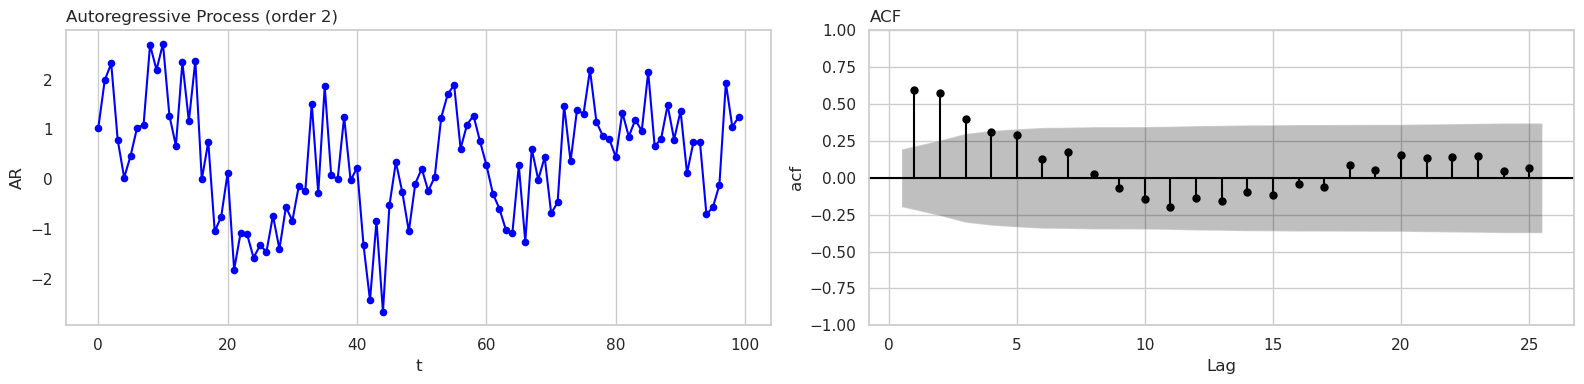

In [12]:
df_ts = AR_df
var = "AR"
title="Autoregressive Process (order 2)"

fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
df_ts[var].plot(color="blue", ax=ax0)
pd.DataFrame({"t":range(df_ts.shape[0]), var:df_ts[var]}).plot(color="blue", kind="scatter", x="t", y=var, ax=ax0)
ax0.set_title(title)
ax0.grid(visible=True, which='both', axis='x')
ax0.grid(visible=False, which='Major', axis='y')

ax1 = axs[1]
sm.graphics.tsa.plot_acf(df_ts[var].dropna(), ax=ax1, lags=25, zero=False, title='ACF')
ax1.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

plt.tight_layout()
plt.show();plt.close()

::: {.callout-note icon=false}

#### ACF and Dynamics for AR Models

This ACF is, as we will see, typical of an stationary AR process. Note that the first ACF values drop to zero in an scillatory pattern but they do not suddenly vanish.In fact, we get **three significantly different from zero coefficients.** This observation will be important below in the context of identification of the right modeling strategy for our data. The pattern of the ACF looks more like a slow fading to zero. Observe also the interesting dynamics in the time plot. Both plots indicate that this is certainly not noise. To visualize more examples of this dynamics let us generate some more **realizations of AR(2) processes with the same characteristic polynomial, where the only change is the noise term**. 

:::


In [13]:
k = 5

AR = np.zeros((n, k))

for j in range(k):
    W = noise_gen(size = n, seed=j)
    
    AR[0, j] = W[0]
    AR[1, j] = -ar_cff[1] * AR[0, j] + W[1]

    for i in range(2, n):
        AR[i, j] = -ar_cff[1] * AR[i - 1, j] - ar_cff[2] * AR[i - 2, j] + W[i]

AR_df2 = pd.DataFrame(AR, columns=["AR"+str(i) for i in range(k)])
AR_df2.head()

,AR0,AR1,AR2,AR3,AR4
0,0.126,0.346,0.189,2.041,-0.652
1,-0.090,0.937,-0.460,-1.875,-0.392
2,0.673,0.816,-0.472,0.813,1.207
3,0.284,-0.563,-2.829,-1.234,0.866
4,-0.104,1.125,0.621,-0.457,-0.749


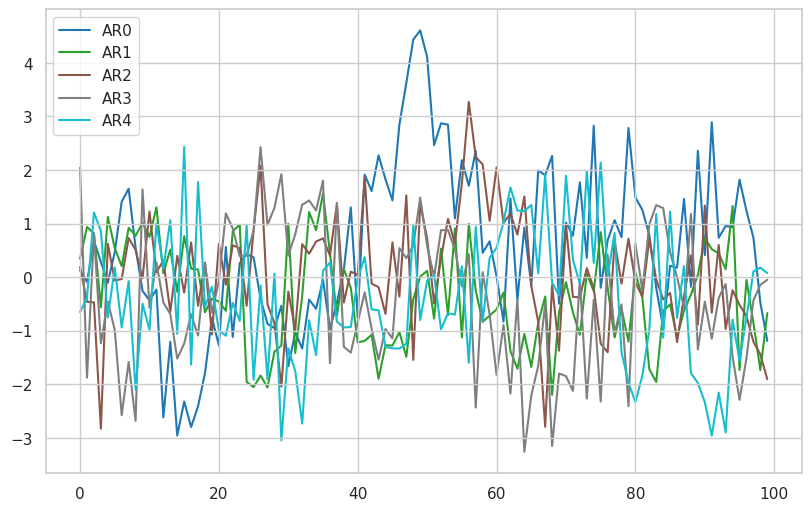

In [14]:
fig, ax = plt.subplots()
AR_df2.plot(ax=ax, zorder=-10, colormap="tab10")
if (k > 10):
    ax.get_legend().remove()

Again, note that the dynamic of this series is quite complex, even when the coefficients are the same for all those series. This provides $AR$ models with a lot of flexibility. Besides, their interpretation as saying that the main drivers of a process are its closest past values is intuitively appealing as a model for many processes we observe in nature or in human activities. 

::: {.callout-note icon=false}

#### Stationarity in AR Processes

Not all AR processes are stationary: as we have said, a random walk is an exampleof AR(1) process, but we know it is not stationary. Recall that the characteristic polynomial o an autoregressive $AR(p)$ is 
$$\Phi(B) = (1-\phi_1B - \cdots - \phi_p B^p)$$
This polynomial provides a very simple characterization of stationarity for this processes: 

**An autoregressive AR(p) process is stationary if and only if the roots of the characteristic polynomial are outside the unit circle.**
$$\Phi(B) = 0 \Rightarrow |B| > 1$$


:::


::: {.callout-tip  icon=false}

### Exercise 001

The roots of the AR(2) process that we have used as example [can be obtained here](https://www.wolframalpha.com/input?i=solve+%281+-+B%2F3+-+B%5E2%2F2+%3D+0%29&lang=es). Is it stationary?

:::

---


#  Moving Average (MA) Processes

::: {.callout-note icon=false}

#### Moving Average Processes Definition in the Non Seasonal Case

A stochastic process $(Y_t)$ is called a **moving average** process if it satisfies the equation:

$$y_{t} = \varepsilon_t + \theta_{1}\varepsilon_{t-1} + \theta_{2}\varepsilon_{t-2} + \cdots + \theta_{q}\varepsilon_{t-q},$$

where:
+ $(\varepsilon_{t})$ is gaussian white noise 
+ $\theta_1, \ldots, \theta_{q}$ are constants, called the **coefficients** of the process. 
+ The number $q$ is the **order** of the process, which is then called an **MA(q) process**.

Any time series which is a realization of a moving average process is called an **moving average time series**. 

:::

---


::: {.callout-note icon=false}

#### Characteristic Polynomial and Invertibility for MA Processes

The **characteristic polynomial**  of the MA(q) process is:
$$
\Theta(B) = 1 + \theta_{1}B + \theta_{2}B^2 + \cdots + \theta_{q}B^q
$$
so yhat the MA process can be written as:
$$
y_t = \Theta(B) \varepsilon_t
$$

Suppose that we have a MA(1) process with $|\theta_1| < 1$
$$
y_t = (1 - \theta_1\,B)\varepsilon_t
$$
then the operator $(1 - \theta_1\,B)$ is **invertible**, meaning that 
$$
\dfrac{1}{1 - \theta_1\,B} = 1 + \theta_1\, B + \theta_1^2\, B^2 + \theta_1^3\, B^2+\dots
$$ 
In partcular this means that an invertible $MA(1)$ process can be considered as an infinite autoregresive process $\text{AR}(\infty)$:
$$
(1 + \theta_1\, B + \theta_1^2\, B^2 + \theta_1^3\, B^2+\dots)y_t = \varepsilon_t
$$
The same ideas apply to general order MA(q) processes, provide they are invertible, that is if **the roots of the characteristic polynomial $\Theta(B)$ are all outside the unit circle of the complex plane.** Ivertibility implies that the $MA(q)$ polynomial is equivalent to a certain $\text{AR}(\infty)$ process. This in turn implies that the MA(q) model possesses some nice mathematical properties (see e.g. the discussion and the video in Section 9.4 of [@hyndman2021fpp3](https://otexts.com/fpp3/MA.html))

::: 

---


::: {.callout-note icon=false}

#### Simulating a Non Seasonal MA(q) Processes with Python

The simulation follows the same structure that we saw in the autoregressive case. Let us simulate the MA(2) process defined by:

$$y_t = \epsilon_{t} + 0.4\,\epsilon_{t–1} - 0.3\,\epsilon_{t–2}$$

Again we need to think of the characteristic polynomial form in order to get the coefficients right in Python:

$$y_t = (1 + 0.4\,B - 0.3\, B^2)\,\epsilon_{t}$$

:::


In [15]:
ma_cff = np.array([1, 0.4, -0.3])
ar_cff = np.array([1,  0,    0]) 

MA = ArmaProcess(ar_cff, ma_cff).generate_sample(nsample=n, distrvs=noise_gen)

MA_df = pd.DataFrame({"MA":MA})

MA_df.head()


,MA
0,1.029
1,2.053
2,1.495
3,-1.007
4,-2.126


Let us plot the time series and its ACF:

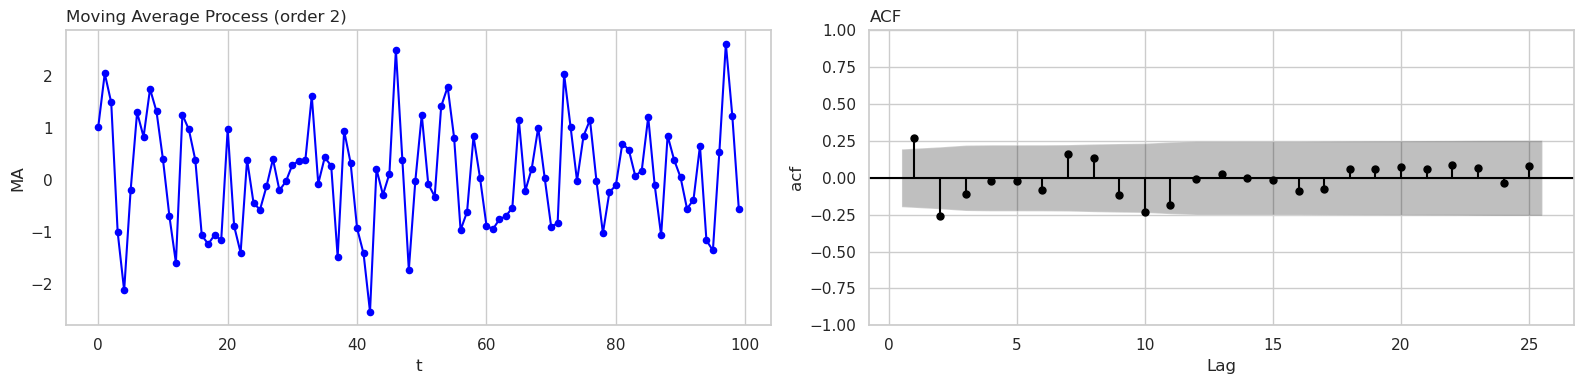

In [16]:
df_ts = MA_df
var = "MA"
title="Moving Average Process (order 2)"

fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
df_ts[var].plot(color="blue", ax=ax0)
pd.DataFrame({"t":range(df_ts.shape[0]), var:df_ts[var]}).plot(color="blue", kind="scatter", x="t", y=var, ax=ax0)
ax0.set_title(title)
ax0.grid(visible=True, which='both', axis='x')
ax0.grid(visible=False, which='Major', axis='y')

ax1 = axs[1]
sm.graphics.tsa.plot_acf(df_ts[var].dropna(), ax=ax1, lags=25, zero=False, title='ACF')
ax1.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

plt.tight_layout()
plt.show();plt.close()

::: {.callout-tip  icon=false}

### Exercise 002

Can you generate this exact time series using a for loop instead of `generate_sample`?

:::

---


::: {.callout-note icon=false}

#### Identifying a Non Seasonal MA(q) or AR(p) with the ACF

The above example illustrates the typical behavior of **the ACF of a moving average MA(q) time series: the autocorrelation coefﬁcients become abruptly non-signiﬁcant after lag q.**

However, we saw that the ACF of the AR(p) example was different and the number of significant coefficients (meaning significantly different from 0) is no indicator of the order of the process. In prder to do this we will use a different plot, called **the PACF, for partial autocorrelation function**. This is a modified version of the ACF. If the ACF k-th coefficient examines the correlation between $y_t$ and $y_{t - k}$, the analogous in the PACF examines coefficient of $y_{t-k}$ in a regression model for $y_t$ using all the lags 
$$y_{t-1}, y_{t-1},\ldots, y_{t-k}$$
as predictors. This means that we are examining the relation between $y_{t}$ and $y_{t - k}$ **while controlling for the effect of the intermediate lags**. that is why these are called *partial* autocorrelation coefficients. 

The way to use the PACF to identify the order of an autoregressive model is simple. **In the PACF of an autoregressive  AR(p) time series: the partial autocorrelation coefﬁcients become abruptly non-signiﬁcant after lag p.**

In Python we can plot the PACF with 

:::


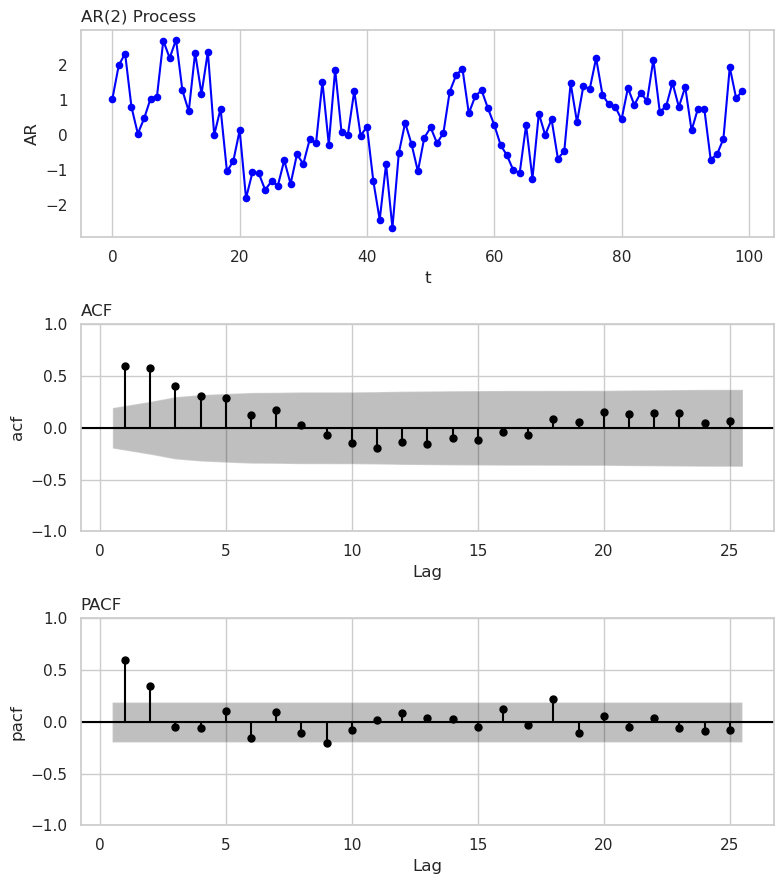

In [17]:
df_ts = AR_df
var = "AR"
title="AR(2) Process"

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=False, sharey=False)

ax0 = axs[0]
df_ts[var].plot(color="blue", ax=ax0)
pd.DataFrame({"t":range(df_ts.shape[0]), var:df_ts[var]}).plot(color="blue", kind="scatter", x="t", y=var, ax=ax0)
ax0.set_title(title)
ax0.grid(visible=True, which='both', axis='x')
ax0.grid(visible=False, which='Major', axis='y')

ax1 = axs[1]
sm.graphics.tsa.plot_acf(df_ts[var].dropna(), ax=ax1, lags=25, zero=False, title='ACF')
ax1.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')


ax2 = axs[2]
sm.graphics.tsa.plot_pacf(df_ts[var].dropna(), ax=ax2, lags=25, zero=False, title='PACF')
ax2.set(ylim=(-1,1), xlabel='Lag', ylabel='pacf')

plt.tight_layout()
plt.show();plt.close()

---


::: {.callout-note  icon=false}

### The PACF for Moving Average Processes

How does the PACF of a MA(q) looks like? Lets us do it for our example.

:::

In [18]:
MA = ArmaProcess([1, 0], [1, -0.999]).generate_sample(nsample=n)

MA_df = pd.DataFrame({"MA":MA})

MA_df.head()


,MA
0,1.624
1,-2.234
2,0.083
3,-0.545
4,1.937


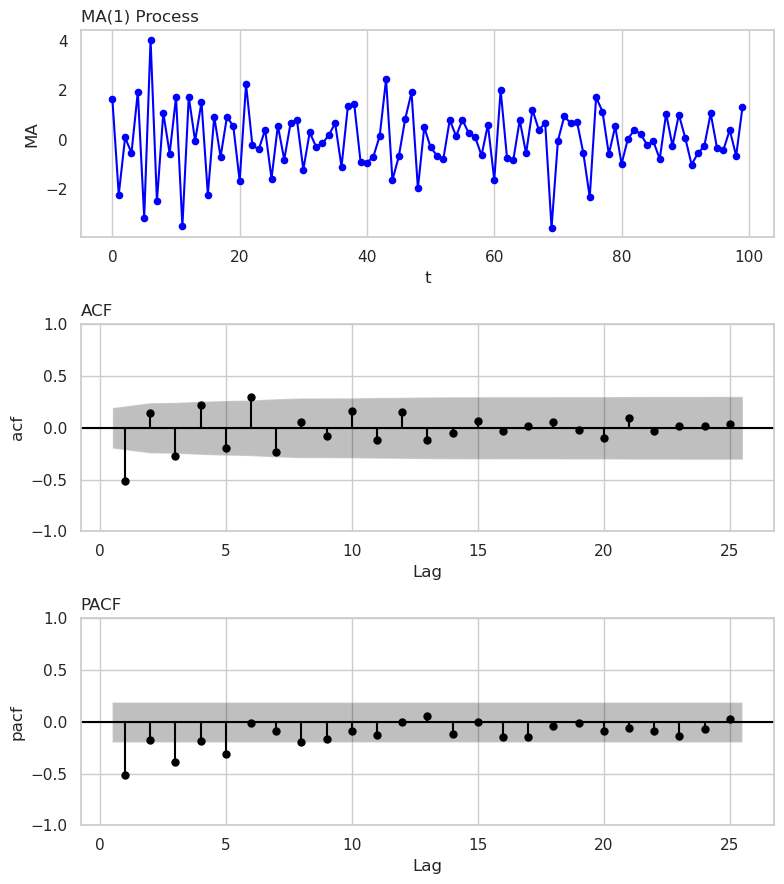

In [19]:
df_ts = MA_df
var = "MA"
title="MA(1) Process"

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=False, sharey=False)

ax0 = axs[0]
df_ts[var].plot(color="blue", ax=ax0)
pd.DataFrame({"t":range(df_ts.shape[0]), var:df_ts[var]}).plot(color="blue", kind="scatter", x="t", y=var, ax=ax0)
ax0.set_title(title)
ax0.grid(visible=True, which='both', axis='x')
ax0.grid(visible=False, which='Major', axis='y')

ax1 = axs[1]
sm.graphics.tsa.plot_acf(df_ts[var].dropna(), ax=ax1, lags=25, zero=False, title='ACF')
ax1.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')


ax2 = axs[2]
sm.graphics.tsa.plot_pacf(df_ts[var].dropna(), ax=ax2, lags=25, zero=False, title='PACF')
ax2.set(ylim=(-1,1), xlabel='Lag', ylabel='pacf')

plt.tight_layout()
plt.show();plt.close()

In this case the situation is reversed: the relevant information for a pure MA process is in the ACF, while the PACF can exhibit a more complex pattern of decay.

---

# ARMA Processes

::: {.callout-note  icon=false}

## Definition of the ARMA(p, q) Process

An stochastic process is an **ARMA(p, q) process** if it satisfies the equation
$$
y_{t} = \phi_{1}y_{t-1} + \cdots + \phi_{p}y_{t-p} + \theta_{1}\varepsilon_{t-1} + \cdots + \theta_{q}\varepsilon_{t-q} + \varepsilon_{t}
$$
where, as usual, $\varepsilon_{t}$ is white noise, and $(p, q)$ are jointly called the order of the process.

The expression of the ARMA(p, q) process in terms of characteristic polynomials is:
$$
\Phi(B)\,y_t = \Theta(B)\varepsilon_t
$$
And the process is stationary and invertible  if the roots of both $\Phi(B)$ and $\Theta(B)$ are outside the complex unit circle.

:::

::: {.callout-note  icon=false}

## Experimenting with the Identification of ARMA(p, q) Processes with the ACF and PACF

In the next code cells first  we will load an external script with a couple of auxiliary functions: `generate_custom_ARMA` and `plot_acf_pacf`. The first one will allow you to choose the (p, q) values and generate a time series corresponding to a random ARMA(p, q) process (guaranteed to be stationary and invertible). Then using the second function you can plot the ACF and PACF of that time series and see if and how it relates to p and q, using the ideas from the previous paragraphs. 

The function `generate_custom_ARMA` will not generate arbitrary order ARMA(p, q) time series, it is in fact limited to values $p, q$ such that  $p + q \leq 2$ as these are the values for the models that we are mostly interested in. 

:::

::: {.callout-warning  icon=false}

## The Identification is Often a Trial and Error Situation

Be warned that it is often not easy to guess the right values of p and q from the ACF and PACF plots. As this identification is part of the modeling process we are going to describe, we are therefore often led to consider several alternative models depending on our choice of p and q. The model fit diagnosis and performance evaluation measures will then be the key to select a final model.

:::

In [20]:
# %run -i "./4_3_auxiliary_ARMA.py"

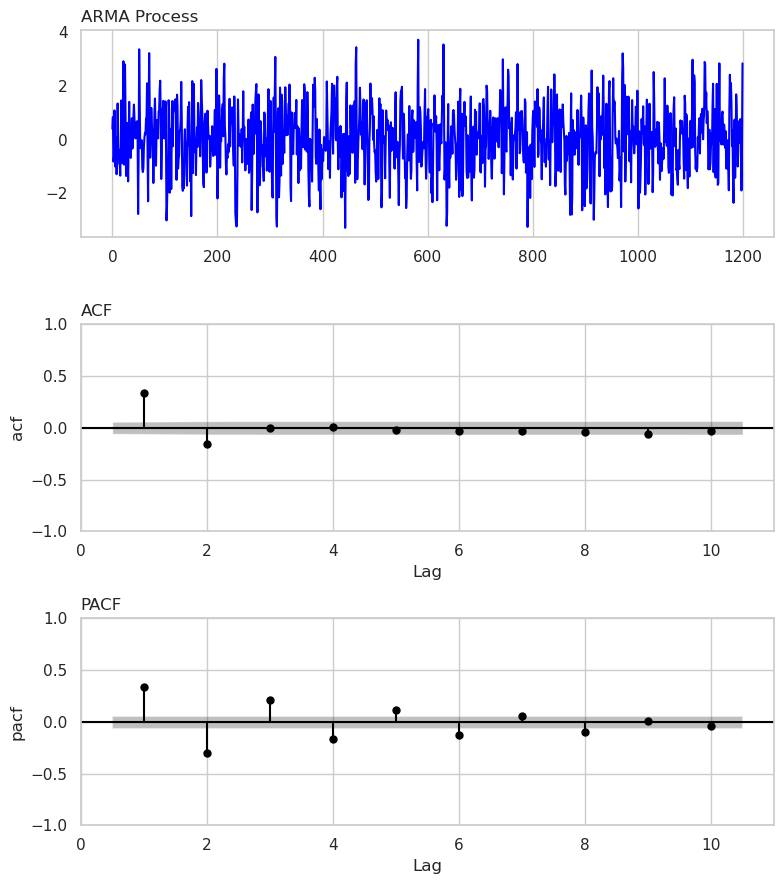

In [21]:
Y_df, p, q, ar_cff, ma_cff, rts_p, rts_q = generate_custom_ARMA(p=0, q=2, size=1200)

plot_acf_pacf(df_ts= Y_df, var="Y", title="ARMA Process" )

plt.show();plt.close()


::: {.callout-tip  icon=false}

### Exercise 003. IMPORTANT!

After experimenting for a while with known values of p and q, you can run the `generate_custom_ARMA` without selecting p, q values. Those values will then be selected at random:

        Y_df, p, q, ar_cff, ma_cff, rts_p, rts_q = generate_custom_ARMA(size=1200)  

After running this code (and without <s>cheating</s> looking at the values of p, q) plot the ACF and PACF. Make an educated guess!

Then run

        print(p, q)
        print(ar_cff, ma_cff)
        print(np.absolute(rts_p), np.absolute(rts_q))
to see the p, q values, the coefficients and the modulus for each root of both characteristic polynomials. 


:::

---

# ARIMA Models

::: {.callout-note  icon=false}

#### ARIMA Meaning

If our series looks stationary, we can try to find an ARMA(p, q) process/model that fits our time series (and verifies the stationarity and invertibility conditions). This strategy often succeeds, as the ARMA family of processes is flexible enough to capture the dynamics of many time series coming from natural phenomena or human related activities. That still holds even if we keep to low order ARMA(p, q) processes, say with $p, q < 5$.

But what if our series is not stationary? Then we can try to apply differences it until it becomes stationary. This is the idea behind the ARIMA model. Here we will introduce the ARIMA model for the case of a non seasonal time series. The seasonal case will be introduced in a section below.


:::

::: {.callout-note  icon=false}

#### Fitting an ARIMA Model with the Box-Jenkins Methodology

The above idea was organized into a methodology by Box and Jenkins in the 1970s. The methodology, described in their book [@Box2015], is based on the following steps:

**Step 1: Data preparation**

1.1 Divide the data in Training and Test.  
1.2 Transform data to stabilize variance if needed (e.g. using BoxCox transformation).  
1.3 Difference data to obtain stationary series if needed.  

**Step 2: Model selection**

2.1 Examine data, ACF and PACF to identify a potential model or models.  

**Step 3: Estimation / Fit**

3.1 Estimate parameters in potential models: fit the model.  

**Step 4: Model Diagnosis**

4.1 Examine the coefficients and residuals.  

**Step 5: Forecasting and Model Comparison**

5.1 Obtain the model forecasts for the test set.  
5.2 Use those forecasts to measure the model performance and compare candidate models.  
5.3 If transformations were applied to stabilize variance or if differencing was required, make sure to transform back the forecasts.

:::

---

::: {.callout-note  icon=false}

#### ARIMA Model Examples

In the following code cells we will show how to apply the Box-Jenkins methodology to  fit an ARIMA model to a time series. We will use both the `ARIMA` class from the `statsmodels` library and from the `Statsforecast` library of the Nixtlaverse. 

The `Arima_examples.csv` file contains five daily time series `Y1, ..., Y5` that can be used as examples to illustrate the methodology. Here we will use `Y2` as an example, leaving the other series for you to experiment with. The EDA can be kept to a minimum: these series do not contain missing values or time gaps.

:::

In [22]:
df_ts = pd.read_csv('Arima_examples.csv', sep=";")
df_ts.head()

,date,Y1,Y2,Y3,Y4,Y5
0,1995-01-01,-0.587,0.994,0.983,0.987,1.022
1,1995-01-02,-1.427,0.985,0.951,0.969,1.071
2,1995-01-03,0.059,1.001,0.933,0.958,1.140
3,1995-01-04,0.653,1.007,0.940,0.999,1.229
4,1995-01-05,-1.788,0.981,0.941,0.952,1.338


In [23]:
df_ts.tail()

,date,Y1,Y2,Y3,Y4,Y5
1091,1997-12-27,-2.237,0.977,1.404,0.847,194512.61
1092,1997-12-28,-1.641,0.983,1.473,0.860,195200.48
1093,1997-12-29,-2.279,0.976,1.512,0.882,195871.34
1094,1997-12-30,-3.625,0.963,1.506,0.872,196544.33
1095,1997-12-31,-1.745,0.982,1.480,0.884,197238.02


Let us check the structure of the dataset using `info`. 

In [24]:
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1096 non-null   object 
 1   Y1      1096 non-null   float64
 2   Y2      1096 non-null   float64
 3   Y3      1096 non-null   float64
 4   Y4      1096 non-null   float64
 5   Y5      1096 non-null   float64
dtypes: float64(5), object(1)
memory usage: 51.5+ KB


In [25]:
df_ts["date"] = pd.to_datetime(df_ts["date"], format="%Y-%m-%d")
df_ts.head()


,date,Y1,Y2,Y3,Y4,Y5
0,1995-01-01,-0.587,0.994,0.983,0.987,1.022
1,1995-01-02,-1.427,0.985,0.951,0.969,1.071
2,1995-01-03,0.059,1.001,0.933,0.958,1.140
3,1995-01-04,0.653,1.007,0.940,0.999,1.229
4,1995-01-05,-1.788,0.981,0.941,0.952,1.338


In [26]:
df_ts.set_index("date", inplace=True, drop=False)
df_ts.index.freq = 'D'
df_ts.head()

,date,Y1,Y2,Y3,Y4,Y5
date,,,,,,
1995-01-01,1995-01-01,-0.587,0.994,0.983,0.987,1.022
1995-01-02,1995-01-02,-1.427,0.985,0.951,0.969,1.071
1995-01-03,1995-01-03,0.059,1.001,0.933,0.958,1.140
1995-01-04,1995-01-04,0.653,1.007,0.940,0.999,1.229
1995-01-05,1995-01-05,-1.788,0.981,0.941,0.952,1.338


Before moving on, let us prepare a version of this data for use with Nixtla. 

In [27]:
df_nx = df_ts.copy()
df_nx.head()

,date,Y1,Y2,Y3,Y4,Y5
date,,,,,,
1995-01-01,1995-01-01,-0.587,0.994,0.983,0.987,1.022
1995-01-02,1995-01-02,-1.427,0.985,0.951,0.969,1.071
1995-01-03,1995-01-03,0.059,1.001,0.933,0.958,1.140
1995-01-04,1995-01-04,0.653,1.007,0.940,0.999,1.229
1995-01-05,1995-01-05,-1.788,0.981,0.941,0.952,1.338


Let us select one of the time series (and drop the rest).

In [28]:
Y = "Y2"
df_ts = df_ts[[Y]].copy()

We use the `plot_acf_pacf` function to plot the series along with its ACF and PACF.

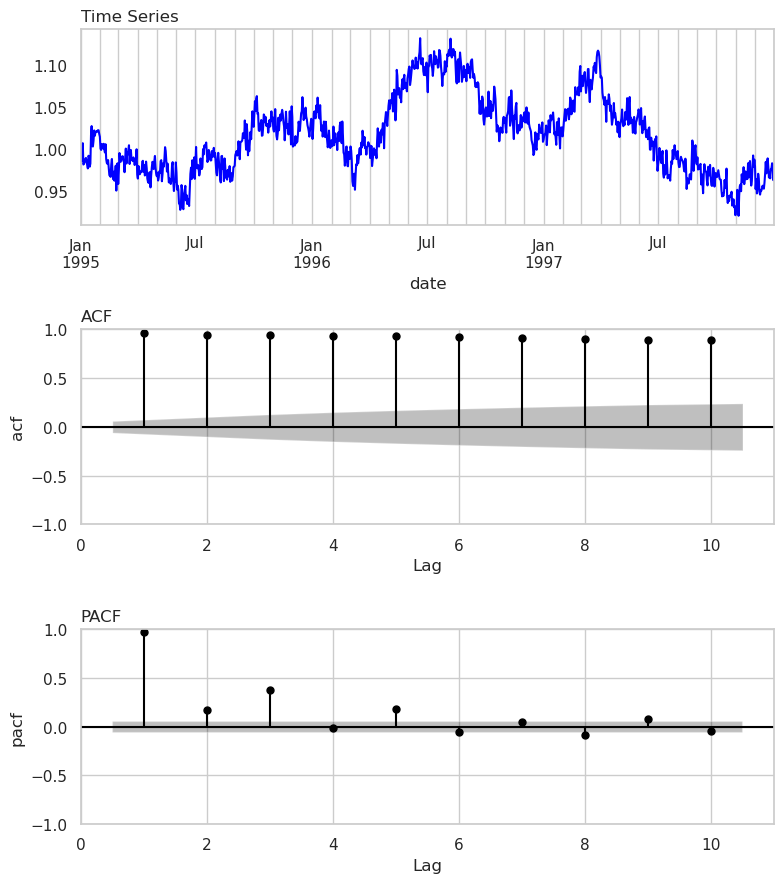

In [29]:
plot_acf_pacf(df_ts=df_ts, var=Y)
plt.show();plt.close()

We can clearly see that the series is not stationary. Both the time plot and the ACF make this clear. So we know that we will have to apply differencing below. But first let us split the data into training and test sets and deal with the variance. We make copies here to avoid warnings below about train and test being *views* of the original data (copies by reference instead of copies by value).

We will use the last week (7 rows) of the series as the test set. As we mentioned when dealing with baseline models, this is common practice in time series forecasting, where instead of using proportions such as 80% of the data for training and 20% for testing, we use some natural temporal division of the data.

In [30]:
fh = 7

y_train = df_ts.iloc[:-fh]
y_test = df_ts.iloc[-fh:]

Let us check the split

In [31]:
y_train.tail()

,Y2
date,
1997-12-20,0.984
1997-12-21,0.989
1997-12-22,0.978
1997-12-23,0.966
1997-12-24,0.970


In [32]:
y_test.head()

,Y2
date,
1997-12-25,0.965
1997-12-26,0.976
1997-12-27,0.977
1997-12-28,0.983
1997-12-29,0.976


In [33]:
y_train.shape, y_test.shape

((1089, 1), (7, 1))

And visualize it:

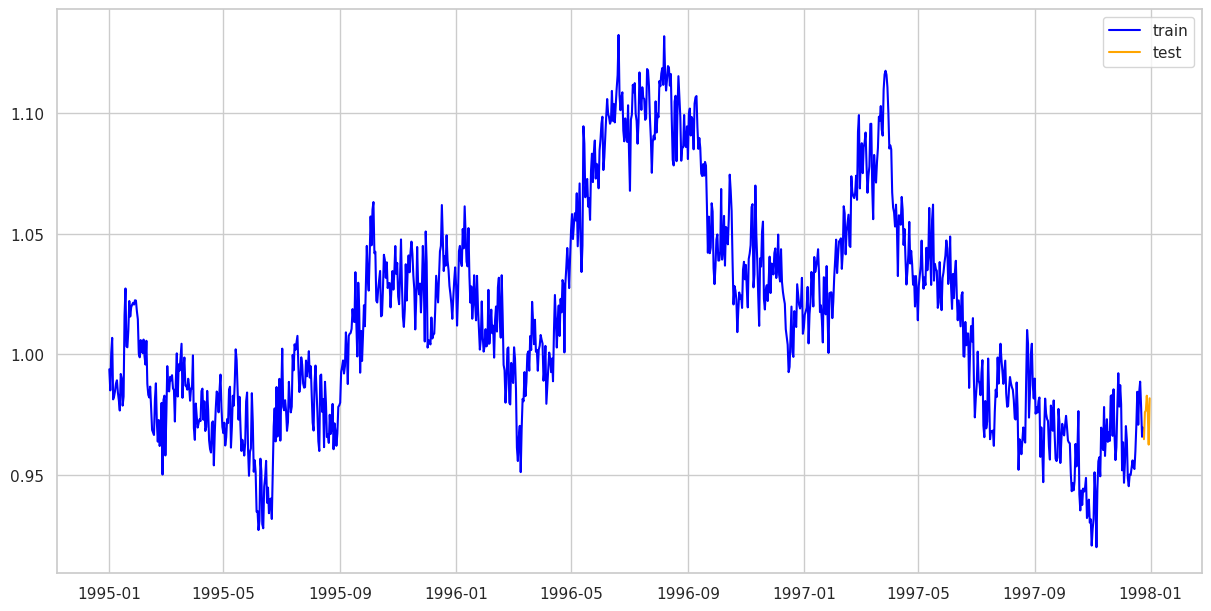

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_train[Y], label='train', color="blue")
ax.plot(y_test[Y], label='test', color="orange")
ax.legend(["train", "test"])
plt.show();plt.close()


::: {.callout-note  icon=false}

#### Stabilizing the Variance. Box-Cox Transformations.

The plot of the training set suggests that the variance of the series is varying with time (the amplitude of the oscillations for the last years is increasing). We are therefore inclined to apply a Box-Cox transformation to the series. Recall that we can formally check homogeneous variance with a Breusch-Pagan test, as we do next.

Also, before proceeding further, note that **seasonality does not appear to be present in the series**. We will therefore only consider a regular ARIMA model, We will deal with the seasonal case below.

:::

This is the code to make the Breusch-Pagan test. We make a copy of the series to apply the required linear regression.

In [35]:
y_train.reset_index(drop=True).reset_index()

,index,Y2
0,0,0.994
1,1,0.985
2,2,1.001
3,3,1.007
4,4,0.981
...,...,...
1084,1084,0.984
1085,1085,0.989
1086,1086,0.978
1087,1087,0.966


In [36]:
y_train

,Y2
date,
1995-01-01,0.994
1995-01-02,0.985
1995-01-03,1.001
1995-01-04,1.007
1995-01-05,0.981
...,...
1997-12-20,0.984
1997-12-21,0.989
1997-12-22,0.978


In [37]:
y_bxcx = y_train.reset_index(drop=True).reset_index()

y_bxcx.columns = ['time', 'value']
y_bxcx
formula = 'value ~ time'
olsr = ols(formula, y_bxcx).fit()

_, breusch_pagan_p_value, _, _ = sms.het_breuschpagan(olsr.resid, olsr.model.exog)
breusch_pagan_p_value 

np.float64(6.613703799815473e-16)

The p-value is very low, so we can reject the null hypothesis of homoscedasticity. We will therefore apply the Box-Cox transformation to the series. In case you decide not to use it you can simply switch `box_cox = false` in the next cell.

In [38]:
from coreforecast.scalers import boxcox, boxcox_lambda

y_train_lambda = boxcox_lambda(y_train[Y], method='guerrero', season_length=1)
y_train_lambda

1.9916213750839233

Using Box-Cox transformation with lambda = 1.9916213750839233


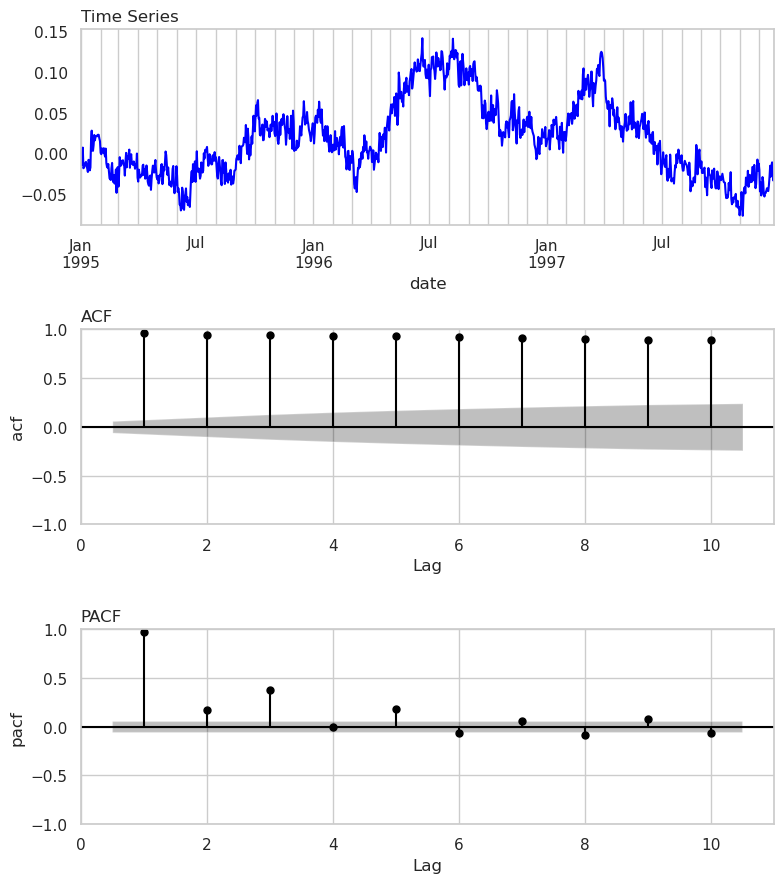

The Y variable now is: Y2_bxcx


In [39]:
use_boxcox = True

if use_boxcox:
    y_train_original = y_train.copy()
    transformed_y_train = boxcox(y_train[[Y]], lmbda=y_train_lambda)
    y_train[Y + "_bxcx"] = transformed_y_train
    print("Using Box-Cox transformation with lambda =", y_train_lambda)
else:
    print
    
Y_original = Y
Y = Y + "_bxcx"
plot_acf_pacf(df_ts=y_train, var=Y)

print(f"The Y variable now is: {Y}")


In [40]:
print(Y)
y_train

Y2_bxcx


,Y2,Y2_bxcx
date,,
1995-01-01,0.994,-6.134e-03
1995-01-02,0.985,-1.479e-02
1995-01-03,1.001,6.222e-04
1995-01-04,1.007,6.916e-03
1995-01-05,0.981,-1.845e-02
...,...,...
1997-12-20,0.984,-1.549e-02
1997-12-21,0.989,-1.122e-02
1997-12-22,0.978,-2.148e-02


The time plot shows that the variance is now more stable. But it clearly still shows a trend and the ACF confirms that the series is not stationary. We will therefore apply regular differencing to the series. 

Before moving on to that recall that when we apply the Box-Cox transformation to the test set we will be using the lambda value from training.

In [41]:
if use_boxcox:
    y_test[Y] = boxcox(y_test[[Y_original]], lmbda=y_train_lambda)

y_test.head()


,Y2,Y2_bxcx
date,,
1997-12-25,0.965,-0.035
1997-12-26,0.976,-0.024
1997-12-27,0.977,-0.023
1997-12-28,0.983,-0.017
1997-12-29,0.976,-0.023


---

::: {.callout-note  icon=false}

#### Deciding if Differencing is Required 

From our EDA we already know that differencing is required, but for the sake of completeness we will include the result of the ADF test before and after differencing. Recall that the ADF Test uses as null hypothesis that the series is non stationary. Therefore if the p-value is small we (reject the null hypothesis and) conclude that the series is stationary. We will also use `ndiffs` from the `pmdarima` library to determine the number of differences required to make the series stationary.

:::

The p-value before differencing is high, clearly suggesting the need for differencing. 

In [42]:
ADF_pvalue = adfuller(y_train[Y])[1]
ADF_pvalue

np.float64(0.5062462887544962)

The result of ndiffs is 1, which is consistent with the ADF test. We will therefore apply first order differencing to the series.

In [43]:
ndiffs, nsdiffs = pmd.arima.ndiffs, pmd.arima.nsdiffs

d =  ndiffs(y_train[Y])

if (d > 0):
    y_train[Y + "_diff"] = y_train[Y].diff(periods=d)
    Ydiff = Y + "_diff"

print(f"Number of applied regular differences = {d}")    
    
    

Number of applied regular differences = 1


The p-value after differencing is very low, confirming that the series is now stationary. Note that we use `dropna` to remove the first value of the series, which after differencing becomes missing and could cause problems in the ADF computation.

In [44]:
ADF_pvalue = adfuller(y_train[Ydiff].dropna())[1]
print(f"The ADF p-value is {ADF_pvalue}")

The ADF p-value is 8.668109801861719e-13


The goal of this step is **not** to actually transform the series and keep working with the differenced series. What we want is the value of `d`, to provide it to the ARIMA model.

---

::: {.callout-note  icon=false}

#### Selecting the ARMA(p, q) Component Candidate

After differencing we check again the ACF and PACF to confirm stationarity and **importantly** to identify the potential values of p and q that define the structure of the ARMA model. These values, together with the value of `d` that we have just obtained, will be used to fit a model to the series of type `ARIMA(p, d, q)` (this is the common convention for the name).

:::

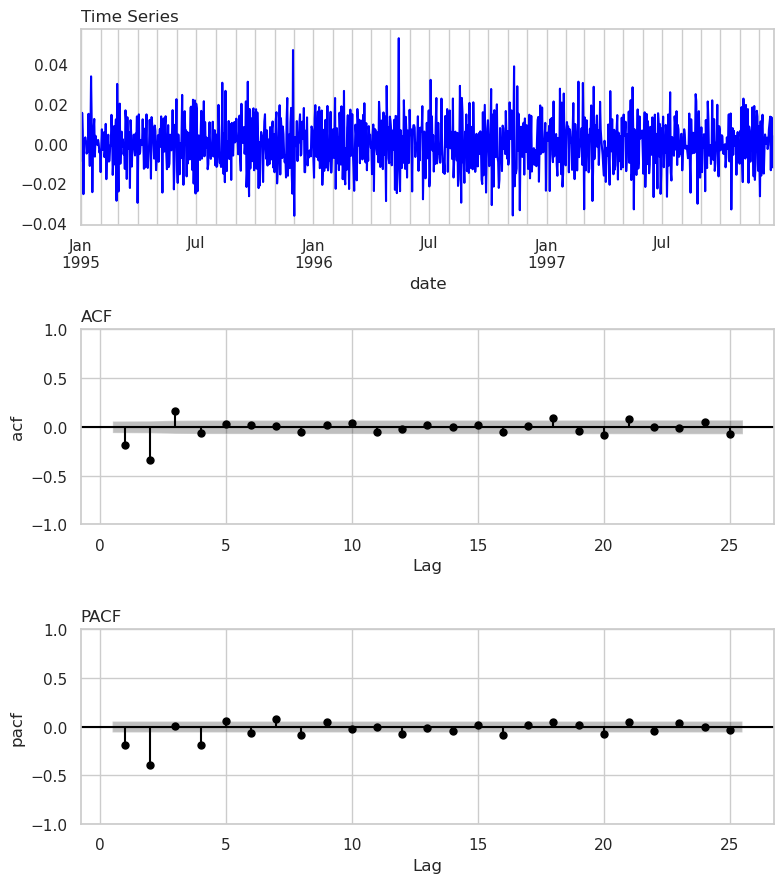

In [45]:
plot_acf_pacf(df_ts=y_train, var=Ydiff, lags=25, plot_points=False)

The above diagram suggests a mix of AR and MA components. We always try to keep the orders low to apply the parsimony principle. But we must pay attention to the (significantly) non-zero coefficients. In particular the second spike in the ACF and PACF suggests p = 2 and q = 2. We will therefore fit an ARIMA(2, 1, 2) model to the series.

In [46]:
p = 2
q = 2

---

<h1 style="color:firebrick">Non seasonal ARIMA with Statsmodels</h1>

::: {.callout-note  icon=false}

#### Fitting an ARIMA Model the statsmodels way

*Note:* up until recently this was essentially the *only* method available in Python. We keep it here because it is still a very common way to fit ARIMA models in Python, especially for statistically oriented discussions.

We will pass those values (p, d, q) to the ARIMA function from the statsmodels library (we call it smARIMA because we will soon use the Nixtla version) and we use the `fit` method to estimate the parameters of the model. Note that, contrary to sklearn, the data is not passed to the `fit` method, but to the `endog` parameter of the ARIMA object. Note also that we pass the non-differenced series to the `fit` method, as the ARIMA object will take care of the differencing. On the other hand, and when they are needed, Box-Cox transformations need to be manually applied before calling ARIMA.

:::

In [47]:
if (d > 0):
    print("Including a constant term in the ARIMA model to account for differencing.")
    trend = "n"
else:
    trend = "t"
arima_model = smARIMA(endog = y_train[Y], order=(p, 1, q), trend = trend).fit() 
model_name = "ARIMA_" + str(p) + "_" + str(d) + "_" + str(q)

Including a constant term in the ARIMA model to account for differencing.


### Statsmodels ARIMA model diagnosis

::: {.callout-note  icon=false}

#### ARIMA Model Diagnosis. Step 1: significance of the coefficients (and possible refitting).

Next we check if the coefficients of this model are statistically significant

:::


In [48]:
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                Y2_bxcx   No. Observations:                 1089
Model:                 ARIMA(2, 1, 2)   Log Likelihood                3385.981
Date:                Wed, 25 Mar 2026   AIC                          -6761.961
Time:                        13:22:35   BIC                          -6737.001
Sample:                    01-01-1995   HQIC                         -6752.513
                         - 12-24-1997                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5085      0.057     -8.892      0.000      -0.621      -0.396
ar.L2         -0.0352      0.057     -0.617      0.537      -0.147       0.077
ma.L1          0.2888      0.050      5.786      0.0

You can see in the table above that the coeficcient for the second autoregressive term is not significant. We will therefore refit the model without this term.

In [49]:
p = 1
arima_model = smARIMA(endog = y_train[Y], order=(p, 1, q), trend=trend).fit() 
model_name = "ARIMA_" + str(p) + "_" + str(d) + "_" + str(q)
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                Y2_bxcx   No. Observations:                 1089
Model:                 ARIMA(1, 1, 2)   Log Likelihood                3385.171
Date:                Wed, 25 Mar 2026   AIC                          -6762.342
Time:                        13:22:35   BIC                          -6742.374
Sample:                    01-01-1995   HQIC                         -6754.784
                         - 12-24-1997                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4432      0.050     -8.869      0.000      -0.541      -0.345
ma.L1          0.2353      0.044      5.378      0.000       0.150       0.321
ma.L2         -0.5337      0.026    -20.815      0.0


Now all the coefficients of the model are significant. 

::: {.callout-note  icon=false}

#### ARIMA Model Diagnosis. Step 2:  Residuals analysis.

Now we inspect the model's residuals to see if the qualify as Gaussian White Noise. We will draw some diagnostic plots and apply the Ljung-Box test to the residuals.

:::

First we extract the residual:

In [50]:
residuals = arima_model.resid[d:]
resid_df = pd.DataFrame({'residuals':residuals})

The residual plots below show:

1. The residuals ACF show no significant coefficients. This is a good sign that the residuals are white noise.
2. The residuals histogram shows a distribution that is close to normal. This is another good sign.
3. The Q-Q plot shows that the residuals behave like the normal distribution. 
4. The time plot of the standardized residuals does not show any discernible pattern, and so they can be considered as white noise.

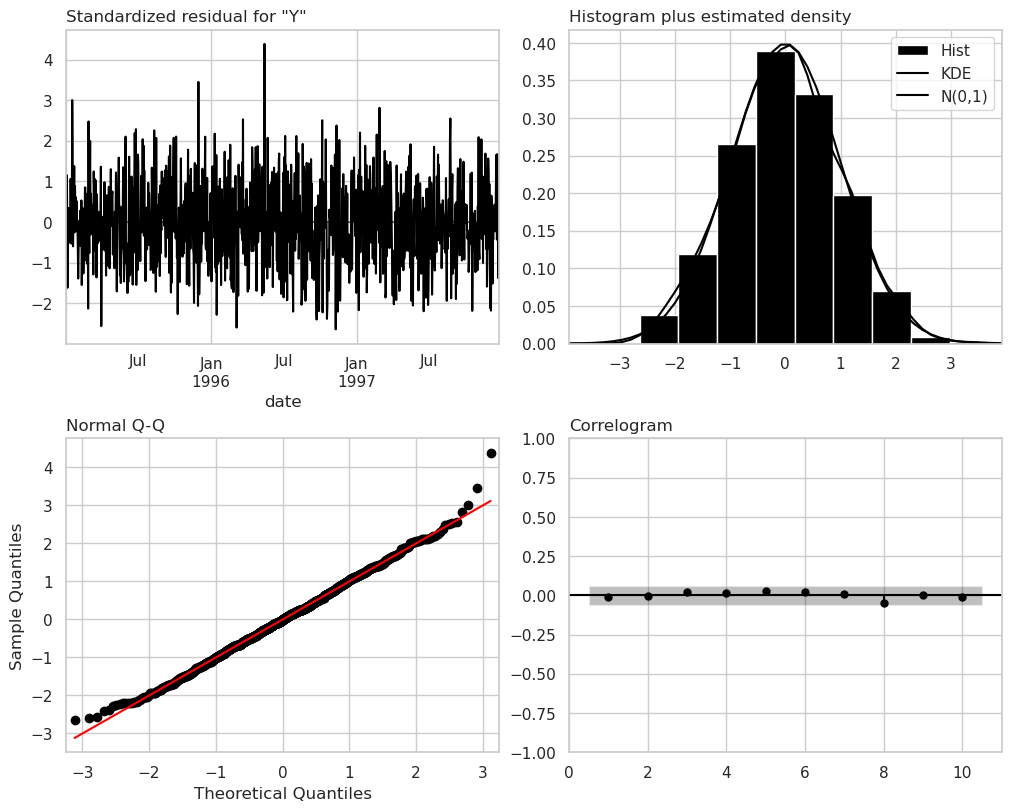

In [51]:
arima_model.plot_diagnostics(figsize=(10, 8), acf_kwargs={'zero':False});
plt.show();plt.close()

Our final residual diagnostic tool is the computation of the Ljung-Box statistic using the first lags of the residuals. All the p-values are over the significance level, so we do not reject the null hypothesis (that the residuals are white noise). 

In [52]:
sm.stats.acorr_ljungbox(residuals, np.arange(1, 10, 1))#.sort_values(by="lb_pvalue", ascending=False)

,lb_stat,lb_pvalue
1,0.171,0.680
2,0.180,0.914
3,0.802,0.849
4,1.061,0.900
5,1.829,0.872
6,2.342,0.886
7,2.457,0.930
8,4.860,0.772
9,4.861,0.846


In [53]:
y_train.index, y_test.index

(DatetimeIndex(['1995-01-01', '1995-01-02', '1995-01-03', '1995-01-04',
                '1995-01-05', '1995-01-06', '1995-01-07', '1995-01-08',
                '1995-01-09', '1995-01-10',
                ...
                '1997-12-15', '1997-12-16', '1997-12-17', '1997-12-18',
                '1997-12-19', '1997-12-20', '1997-12-21', '1997-12-22',
                '1997-12-23', '1997-12-24'],
               dtype='datetime64[ns]', name='date', length=1089, freq='D'),
 DatetimeIndex(['1997-12-25', '1997-12-26', '1997-12-27', '1997-12-28',
                '1997-12-29', '1997-12-30', '1997-12-31'],
               dtype='datetime64[ns]', name='date', freq='D'))

### Visualizing the predictions for the test set

First things first, let us get those predictions:

In [54]:
test_pred = arima_model.predict(start=y_test.index[0], end=y_test.index[-1])
test_pred

1997-12-25   -0.023
1997-12-26   -0.027
1997-12-27   -0.025
1997-12-28   -0.026
1997-12-29   -0.026
1997-12-30   -0.026
1997-12-31   -0.026
Freq: D, Name: predicted_mean, dtype: float64

Now we plot them alongside with the true values:

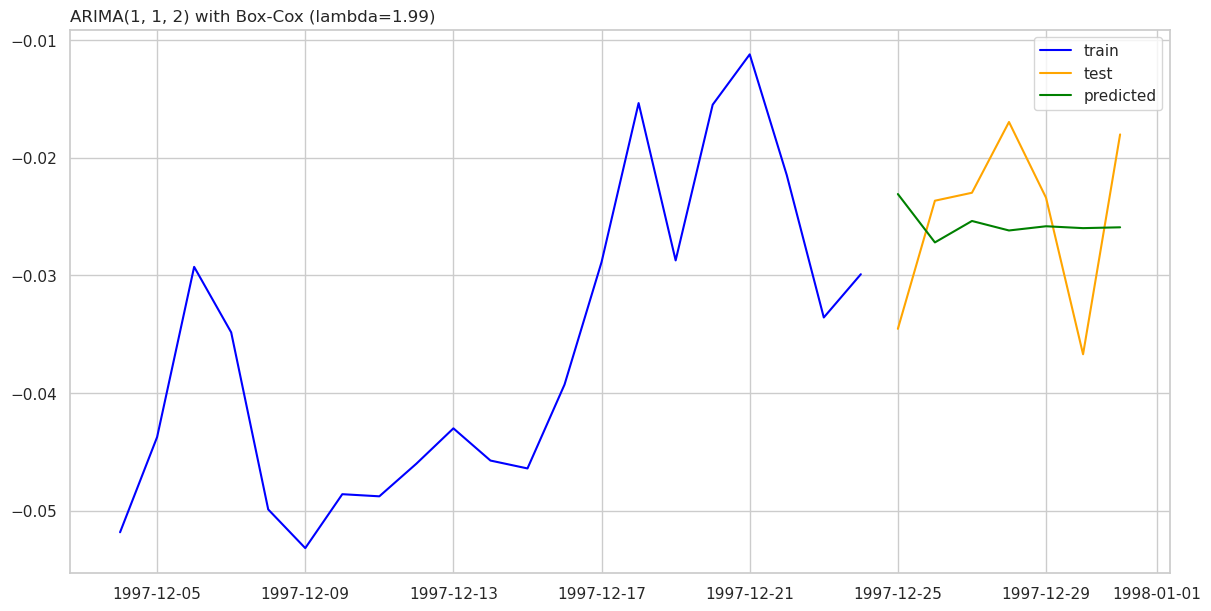

In [55]:
plot_df = y_test.copy()
if use_boxcox:
    plot_df['y'] = boxcox(plot_df[Y_original], lmbda=y_train_lambda)


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_train[Y].tail(3 * fh), label='train', color  = "blue")
ax.plot(plot_df['y'], label='test', color='orange')
ax.plot(test_pred, label='predicted', color = "green")
ax.legend(["train", "test", "predicted"])
if use_boxcox:
    ax.set_title(f"ARIMA({p}, {d}, {q}) with Box-Cox (lambda={y_train_lambda:.2f})")
else:
    ax.set_title(f"ARIMA({p}, {d}, {q}) without Box-Cox")
plt.show();plt.close()  

::: {.callout-important icon=false}

##### Be mindful of the the scale

If we have used a transformation, such as Box-Cox, then in this plot **we are using the transformed scale**. If you want the original scale you need to apply the inverse transformation, for example [using this link to the Nixtla documentation for the **inverse Box-Cox transformation**.](https://nixtlaverse.nixtla.io/coreforecast/scalers#inv_boxcox)

This is also important for **performance metrics, such as the RSME**. WHen comparing models, **make sure that all your metrics apply to data in the same scale**.

:::

### Performance metrics for the test set using ARIMA from Statsmodels

We compute the RMSE and MAPE using their definitions. **See the warning above about the scale.**

In [56]:
test_rmse = np.sqrt(np.mean((y_test[Y] - test_pred)**2))
test_mape = np.mean(np.abs((y_test[Y] - test_pred) / y_test[Y])) * 100

print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAPE: {test_mape:.3f}")
# test_mape = mape(y_test.values, test_pred)

Test RMSE: 0.008
Test MAPE: 28.041


### Cross Validation with Statsmodels (not doing that!)

You may have noticed that we have not discussed how to perform cross validation with this ARIMA model from Statsmodels. We could do that (in fact we used to), but that involves writing our own custom validation loops, which ia an error-prone strategy. Therefore we will refrain from doing that, and we defer a proper validation for the Nixtla version of the model, where the use of `evaluate` will make things much easier for us.

---

<h1 style="color:firebrick">Non seasonal ARIMA with Nixtla</h1>

::: {.callout-note  icon=false}

#### Fitting an ARIMA Model the Nixtla way

Now we will essentially repeat the above steps using the `ARIMA` class from the Nixtla Stasforecast library. 

:::

First we rename the datetime column:

In [57]:
df_nx.rename(columns={"date":"ds"}, inplace=True)
df_nx.head()

,ds,Y1,Y2,Y3,Y4,Y5
date,,,,,,
1995-01-01,1995-01-01,-0.587,0.994,0.983,0.987,1.022
1995-01-02,1995-01-02,-1.427,0.985,0.951,0.969,1.071
1995-01-03,1995-01-03,0.059,1.001,0.933,0.958,1.140
1995-01-04,1995-01-04,0.653,1.007,0.940,0.999,1.229
1995-01-05,1995-01-05,-1.788,0.981,0.941,0.952,1.338


Now we reset the index:

In [58]:
df_nx.reset_index(drop=True, inplace=True)
df_nx.head()

,ds,Y1,Y2,Y3,Y4,Y5
0,1995-01-01,-0.587,0.994,0.983,0.987,1.022
1,1995-01-02,-1.427,0.985,0.951,0.969,1.071
2,1995-01-03,0.059,1.001,0.933,0.958,1.140
3,1995-01-04,0.653,1.007,0.940,0.999,1.229
4,1995-01-05,-1.788,0.981,0.941,0.952,1.338


To make a proper nixtla-friendly use of the different time series Y1,...,Y5 we are going to use the `melt` function to pivot the table into *long format*:

In [59]:
df_nx = pd.melt(
    df_nx, 
    id_vars=['ds'], 
    value_vars=['Y1', 'Y2', 'Y3', 'Y4', 'Y5'],
    var_name='unique_id', 
    value_name='y'
)
df_nx

,ds,unique_id,y
0,1995-01-01,Y1,-0.587
1,1995-01-02,Y1,-1.427
2,1995-01-03,Y1,0.059
3,1995-01-04,Y1,0.653
4,1995-01-05,Y1,-1.788
...,...,...,...
5475,1997-12-27,Y5,194512.610
5476,1997-12-28,Y5,195200.480
5477,1997-12-29,Y5,195871.340
5478,1997-12-30,Y5,196544.330


And now we select the one we want using `query`

In [60]:
df_nx = df_nx.query("unique_id == 'Y2'").reset_index(drop=True)

::: {.callout-warning icon=false}

##### About the use of melt here

In this example we could have just drop the other columns and use some column operations to get the same result. But in the future you may need to keep all the time series and then `melt` provides a proper and easy way of getting the `unique_id` column we need.

:::

### Make the split

Just as before

In [61]:
y_nx_train = df_nx.iloc[:-fh]
y_nx_test = df_nx.iloc[-fh:]

In [62]:
y_nx_train.tail() 

,ds,unique_id,y
1084,1997-12-20,Y2,0.984
1085,1997-12-21,Y2,0.989
1086,1997-12-22,Y2,0.978
1087,1997-12-23,Y2,0.966
1088,1997-12-24,Y2,0.970


In [63]:
y_nx_test.head()

,ds,unique_id,y
1089,1997-12-25,Y2,0.965
1090,1997-12-26,Y2,0.976
1091,1997-12-27,Y2,0.977
1092,1997-12-28,Y2,0.983
1093,1997-12-29,Y2,0.976


And visualize it

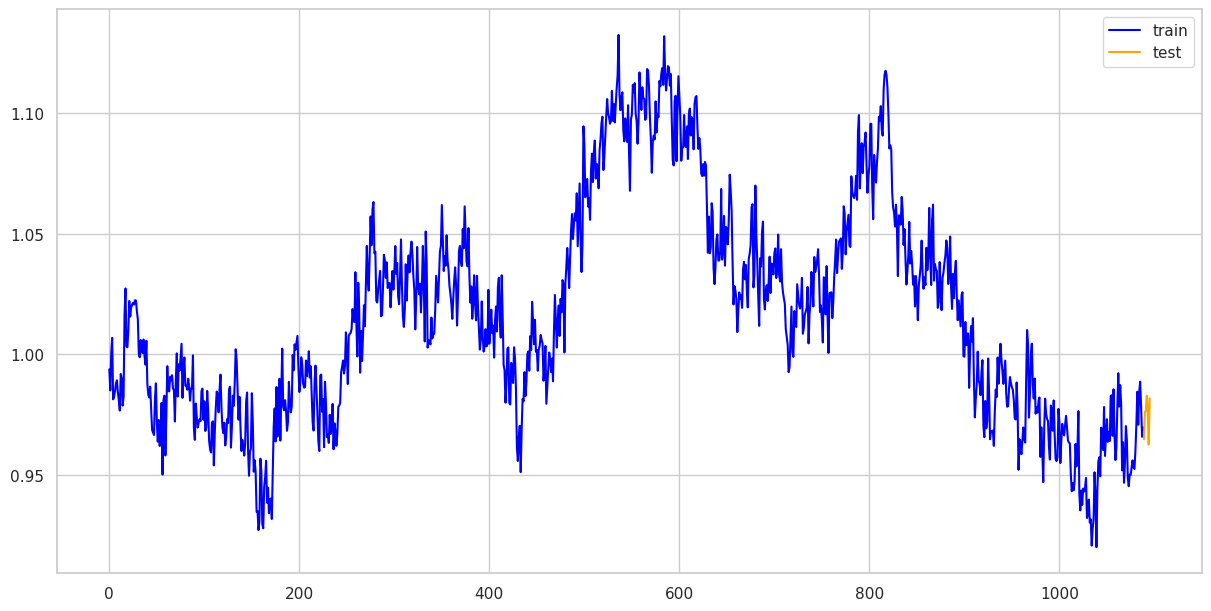

In [64]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_nx_train['y'], label='train', color='blue')
ax.plot(y_nx_test['y'], label='test', color='orange')
ax.legend(["train", "test"])
plt.show();plt.close()

### Stabilizing the variance 

We have already seen this, but we want to provide you with a complete standalone processing based in the Nixtla version of things:

In [65]:
y_bxcx = y_nx_train.drop(columns=["unique_id", "ds"]).reset_index()

y_bxcx.columns = ['time', 'value']
y_bxcx
formula = 'value ~ time'
olsr = ols(formula, y_bxcx).fit()

_, breusch_pagan_p_value, _, _ = sms.het_breuschpagan(olsr.resid, olsr.model.exog)
breusch_pagan_p_value 

np.float64(6.613703799815473e-16)

The p-value is very low, so we can reject the null hypothesis of homoscedasticity. We will therefore apply the Box-Cox transformation to the series. In case you decide not to use it you can simply switch `box_cox = false` in the next cell.

In [66]:
from coreforecast.scalers import boxcox, boxcox_lambda

y_nx_train_lambda = boxcox_lambda(y_nx_train['y'], method='guerrero', season_length=1)
y_nx_train_lambda

1.9916213750839233

In [67]:
use_boxcox = True

if use_boxcox:
    y_nx_train_original = y_nx_train.copy()
    transformed_y_train = boxcox(y_nx_train[['y']], lmbda=y_train_lambda)
    y_nx_train['y'] = transformed_y_train
    y_nx_train['unique_id'] = Y_original
    print("Using Box-Cox transformation with lambda =", y_train_lambda)
else:
    print("Not using Box-Cox transformation.")    
    


Using Box-Cox transformation with lambda = 1.9916213750839233


**Remember our warning about the scale when using Box-Cox.** In particular, if you use it make sure to include the transformed test values below in the corresponding performance evaluations,

In [68]:
if use_boxcox:
    transformed_y_test = boxcox(y_nx_test[['y']], lmbda=y_train_lambda)
    y_nx_test['y'] = transformed_y_test

#### Deciding about Differencing and choosing the ARMA structure 


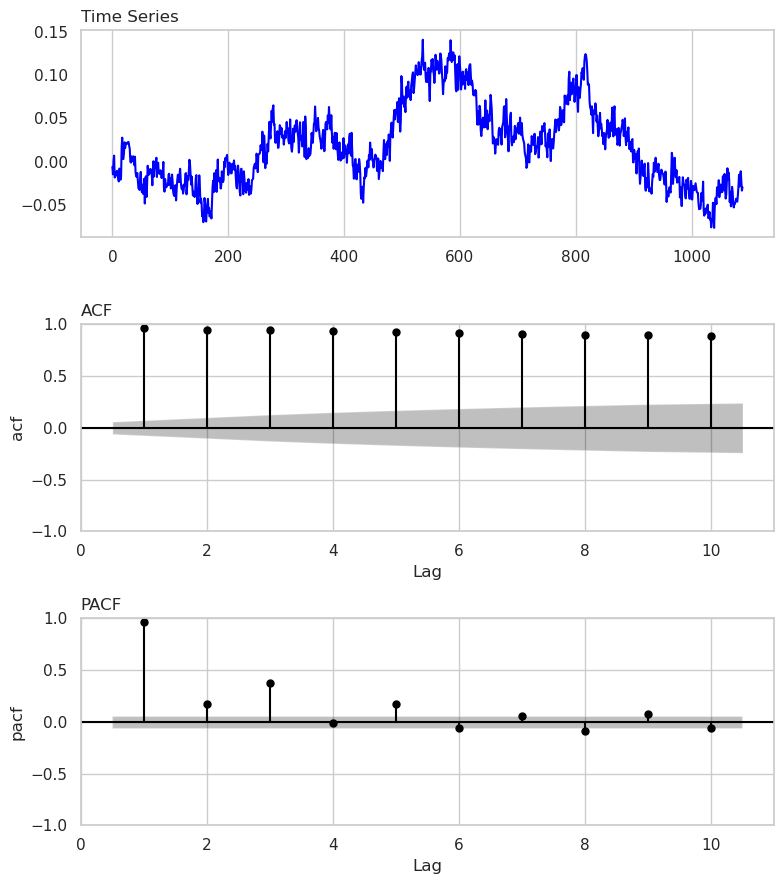

In [69]:

plot_acf_pacf(df_ts=y_nx_train, var='y')


::: {.callout-warning  icon=false}

#### Be careful with automatic procedures!

Note that here we are using a different version, this one is from Nixtla, while ndiffs and nsdiffs belong to pmdarima (another forecasting library). 

:::

We are making a copy of the data for this exploratory part of the analysis:

In [70]:
y_nx_train_EDA = y_nx_train.copy()

Next we apply the Nixtla version for regular differencing called `num_diffs`:

In [71]:
from coreforecast.differences import num_seas_diffs, num_diffs
d = num_diffs(y_nx_train_EDA['y'].dropna())
print(f"Number of suggested regular differences = {d}")   


Number of suggested regular differences = 1


#### Regular Differencing

Regardless of the above automatic results, look at the almost linear decay in the values of the ACF. We will therefore apply a regular difference.

In [72]:
d = 1

if (d > 0) :
    y_nx_train_EDA["y"] = y_nx_train_EDA["y"].diff(periods = d)

print(f"Number of applied regular differences = {d}")   
    
    

Number of applied regular differences = 1


Now the plots and all of our checks indicate that the time series looks stationary (but with the unresolved problem of the variance depending on time):

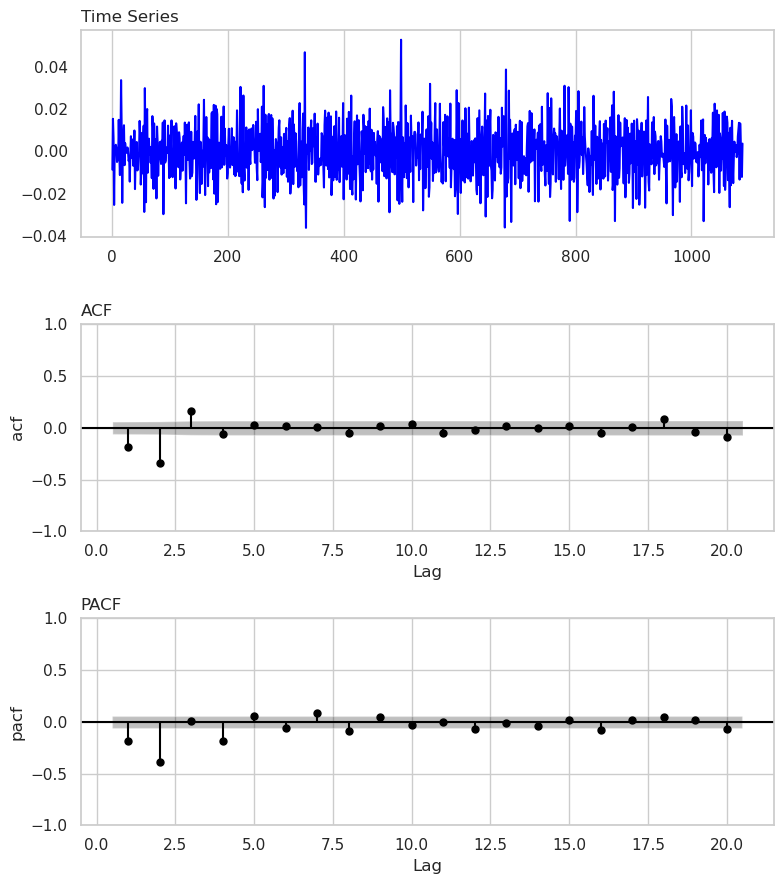

In [73]:
plot_acf_pacf(df_ts=y_nx_train_EDA, var='y', lags= 20)
plt.show();plt.close()  

And the formal checks:

In [74]:
ADF_pvalue = adfuller(y_nx_train_EDA['y'].dropna())[1]
print(f"The ADF p-value is {ADF_pvalue}, the null hypothesis of non-stationarity is {'rejected' if ADF_pvalue < 0.05 else 'not rejected'}")
KPSS_pvalue = kpss(y_nx_train_EDA['y'].dropna())[1]
print(f"The KPSS p-value is {KPSS_pvalue}, the null hypothesis of stationarity is {'rejected' if KPSS_pvalue < 0.05 else 'not rejected'}")

The ADF p-value is 8.668109801861719e-13, the null hypothesis of non-stationarity is rejected
The KPSS p-value is 0.1, the null hypothesis of stationarity is not rejected


---

#### Regular Component

To identify the regular component of the model we use the ACF and PACF of the differenced time series. 

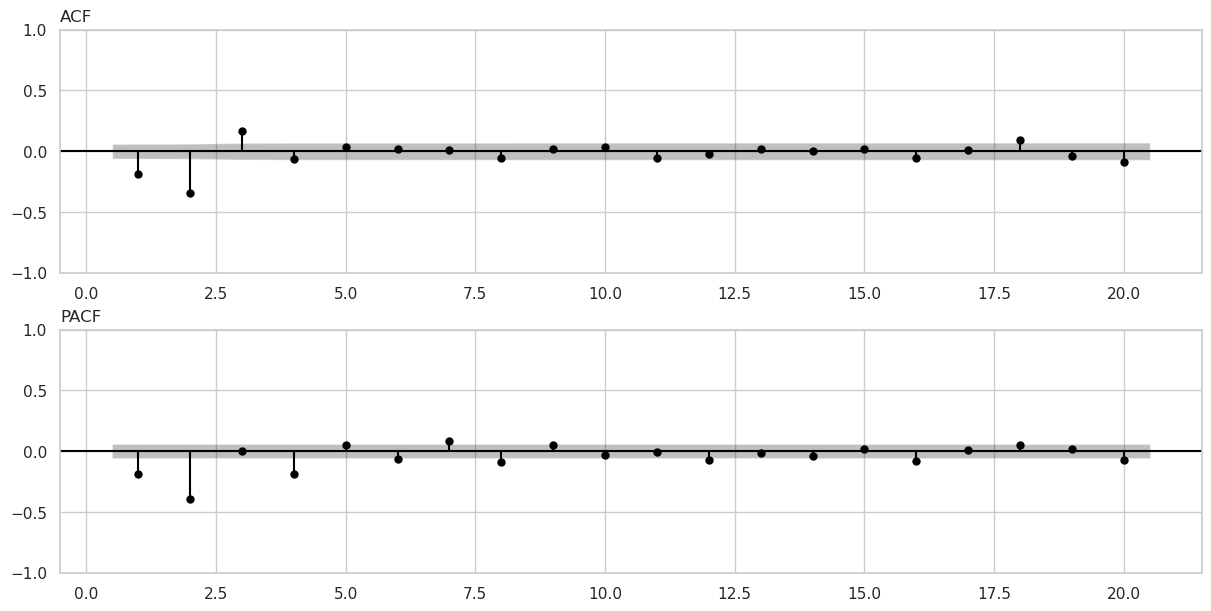

In [75]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

sm.graphics.tsa.plot_acf(y_nx_train_EDA['y'].dropna(), ax=ax[0], lags= 20 , zero=False, title='ACF')

sm.graphics.tsa.plot_pacf(y_nx_train_EDA['y'].dropna(), ax=ax[1], lags= 20, zero=False, title='PACF')

plt.show();plt.close()


The pattern in these values suggests that  AR and MA may both be present. So  we can try an initial guess such as the following:

In [76]:
p = 1
q = 2

### Check the ARIMA structure

In [77]:
if use_boxcox:
    print(f"Fitting an ARIMA model on Box-Cox transformed data with lambda = {y_train_lambda:.4f}")
else:
    print("Fitting an ARIMA model on original data without Box-Cox transformation.")
print("And this structure: ")
print(f"(p, d, q)=({p}, {d}, {q}))")

Fitting an ARIMA model on Box-Cox transformed data with lambda = 1.9916
And this structure: 
(p, d, q)=(1, 1, 2))


## Defining and fitting the Nixtla Arima model (and a  baseline)

We will now fit the Arima model using the results of the exploratory steps above. We use a naive model as baseline to compare it with the more advanced ARIMA model. 

In [78]:
if d > 0:
    print("Including a constant term in the ARIMA model to account for differencing.")
    include_constant = True


naive_method = Naive(alias="naive1")

models = [ARIMA(order=(p, d, q), alias="arima1"), naive_method]

y_models1 = StatsForecast(models=models, freq="D", n_jobs=-1)
y_models1

Including a constant term in the ARIMA model to account for differencing.


StatsForecast(models=[arima1,naive1])

We fit the models:

In [79]:
y_models1.fit(y_nx_train)

StatsForecast(models=[arima1,naive1])

### Understanding the structure of the Nixtla model object

To get a better understanding of this modeling step, is good to examine the structure of the model object we have created. In the cell below:
+ `y_models1.uids` identifies the time series of interest when there is more than one. It is returned as a numpy array.
+ `idx` locates the position for that time series 

When we have more than one model we use the model position in the list of models (0 for ARIMA in our case) and this `idx` to locate what we want. That is why we have that `[0][0]` selectors below.

In [80]:
print(f"y_models1.uids = {y_models1.uids}, {type(y_models1.uids)}")
idx = np.where(y_models1.uids == Y_original)[0][0]
print("----------------------------------")
print(f"Index for {Y_original}: {idx}")


y_models1.uids = 0    Y2
Name: unique_id, dtype: object, <class 'pandas.core.series.Series'>
----------------------------------
Index for Y2: 0


The model object is actually a dictionary:

In [81]:
model_obj = y_models1.fitted_[idx, 0].model_
model_obj


{'coef': {'ar1': np.float64(-0.48635439903751854),
  'ma1': np.float64(0.2726073958751746),
  'ma2': np.float64(-0.5363554262021493)},
 'sigma2': np.float64(0.0001162607225852089),
 'var_coef': array([[ 0.00152858, -0.00143618, -0.0005651 ],
        [-0.00143618,  0.00140874,  0.00047156],
        [-0.0005651 ,  0.00047156,  0.00026829]]),
 'mask': array([ True,  True,  True]),
 'loglik': np.float64(3386.090027340496),
 'aic': np.float64(-6764.180054680992),
 'arma': (1, 2, 0, 0, 1, 1, 0),
 'residuals': array([-0.00000613, -0.00761576,  0.01236079, ...,  0.00011055,
        -0.01516309,  0.00198413], shape=(1089,)),
 'code': 2,
 'n_cond': 0,
 'nobs': np.int64(1088),
 'model': {'phi': array([-0.4863544]),
  'theta': array([ 0.2726074 , -0.53635543]),
  'delta': array([1.]),
  'Z': array([1., 0., 0., 1.]),
  'a': array([ 0.00367565,  0.0086737 , -0.0010642 , -0.03357483]),
  'P': array([[ 0.,  0.,  0.,  0.],
         [ 0.,  0., -0.,  0.],
         [ 0., -0.,  0., -0.],
         [ 0.,  0.

And we can use `get` to access the information in it as follows (e.g. for the coefficients of ARIMA): 

In [82]:
coefs = model_obj.get('coef', [])
coefs, len(coefs)

({'ar1': np.float64(-0.48635439903751854),
  'ma1': np.float64(0.2726073958751746),
  'ma2': np.float64(-0.5363554262021493)},
 3)

Similary we can get the ARIMA structure:

In [83]:
p, q, P, Q, s, d, D = model_obj['arma']
print(f"ARIMA order: (p={p}, d={d}, q={q}) x (P={P}, D={D}, Q={Q})[{s}]")

ARIMA order: (p=1, d=1, q=2) x (P=0, D=0, Q=0)[1]


We can arrange in a nice looking table like this

In [84]:
coef_names = []
if p > 0: coef_names += [f'ar.L{i+1}' for i in range(p)]
if q > 0: coef_names += [f'ma.L{i+1}' for i in range(q)]
if P > 0: coef_names += [f'ar.S.L{i+1}' for i in range(P)]
if Q > 0: coef_names += [f'ma.S.L{i+1}' for i in range(Q)]
 
pd.DataFrame({'coef': coefs.values()}, index=coef_names)

,coef
ar.L1,-0.486
ma.L1,0.273
ma.L2,-0.536


## Diagnosing the Nixtla Arima model

::: {.callout-note  icon=false}

#### ARIMA Model Diagnosis. Step 1: significance of the coefficients (and possible refitting).

Next we check if the coefficients of this model are statistically significant

:::


In order to do that we will use an auxiliary function. But it requires that we get the model's residuals first. We begin with the fitted values:

In [85]:
y_models1.forecast(df=y_nx_train, h=fh, fitted=True)
fitted = y_models1.forecast_fitted_values()['arima1']
fitted


0      -6.128e-03
1      -7.170e-03
2      -1.174e-02
3       1.481e-04
4      -1.072e-03
          ...    
1084   -3.280e-02
1085   -1.486e-02
1086   -2.159e-02
1087   -1.841e-02
1088   -3.188e-02
Name: arima1, Length: 1089, dtype: float32

And we use them to get the residuals:

In [86]:
residuals  = y_nx_train['y'] - fitted
residuals

0      -6.134e-06
1      -7.616e-03
2       1.236e-02
3       6.768e-03
4      -1.738e-02
          ...    
1084    1.731e-02
1085    3.647e-03
1086    1.106e-04
1087   -1.516e-02
1088    1.984e-03
Length: 1089, dtype: float32

This is the auxiliary function we mentioned:

In [87]:
%run -i  "nixtla_summary_table.py"

<Figure size 800x500 with 0 Axes>

And it provides this table, that shows that all the coefficients are significant:

In [88]:
nixtla_summary_table(sf_model=y_models1, model_idx=0,unique_id=Y_original, residuals=residuals)

                             Nixtla Summary Results                             


,Model,Log Likelihood,AIC,BIC,Sigma2
0,"ARIMA(1,1,2)(0,0,0)[1]",3386.090,-6764.180,-6744.212,0.00012


--------------------------------------------------------------------------------


,coef,std err,z,P > |z|,[0.025,0.975]
ar1,-0.486,0.001,-470.058,0.0,-0.488,-0.484
ma1,0.273,0.001,263.473,0.0,0.271,0.275
ma2,-0.536,0.001,-518.383,0.0,-0.538,-0.534


For ease of reference we duplicate here the Statsmodel analogue:

In [89]:
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                Y2_bxcx   No. Observations:                 1089
Model:                 ARIMA(1, 1, 2)   Log Likelihood                3385.171
Date:                Wed, 25 Mar 2026   AIC                          -6762.342
Time:                        13:22:36   BIC                          -6742.374
Sample:                    01-01-1995   HQIC                         -6754.784
                         - 12-24-1997                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4432      0.050     -8.869      0.000      -0.541      -0.345
ma.L1          0.2353      0.044      5.378      0.000       0.150       0.321
ma.L2         -0.5337      0.026    -20.815      0.0

::: {.callout-note  icon=false}

#### ARIMA Model Diagnosis. Step 2:  Residuals analysis.

Now we inspect the model's residuals to see if the qualify as Gaussian White Noise. We will draw some diagnostic plots and apply the Ljung-Box test to the residuals.

:::

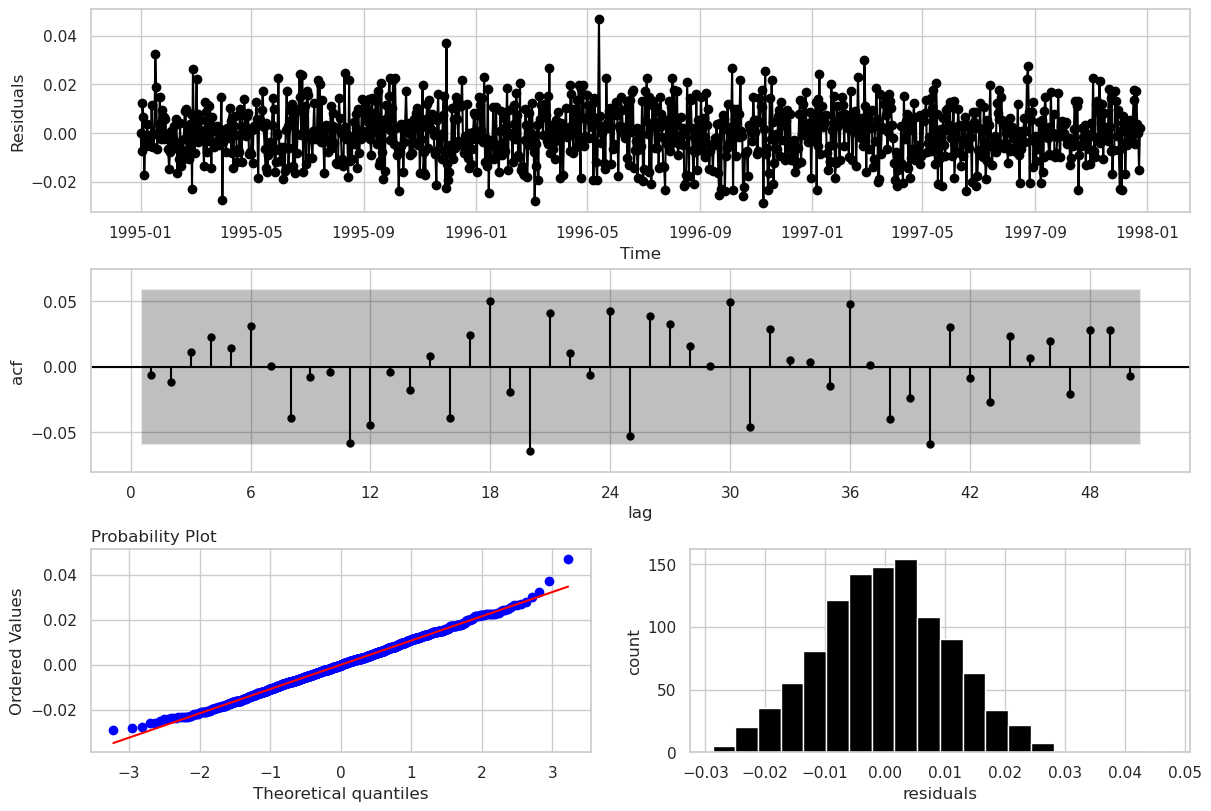

In [90]:
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "acf"] , ["qq", "hist"]], figsize=(12, 8))
axes["resid"].plot(y_nx_train["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Time", ylabel="Residuals")
axes["qq"].set_title("QQ Plot")
stats.probplot(residuals, dist="norm", plot=axes["qq"])
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True, lags=50,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

And we perform the **Ljung-Box test**

In [91]:
ljung_box = acorr_ljungbox(residuals, lags=10)
ljung_box

,lb_stat,lb_pvalue
1,0.041,0.839
2,0.192,0.909
3,0.319,0.956
4,0.890,0.926
5,1.112,0.953
6,2.180,0.902
7,2.180,0.949
8,3.875,0.868
9,3.941,0.915
10,3.961,0.949


#### Visualizing predicted vs real

In [92]:
y_models1_pred = y_models1.predict(h=fh)
y_models1_pred.head(min(10, fh))

,unique_id,ds,arima1,naive1
0,Y2,1997-12-25,-0.023,-0.03
1,Y2,1997-12-26,-0.027,-0.03
2,Y2,1997-12-27,-0.025,-0.03
3,Y2,1997-12-28,-0.026,-0.03
4,Y2,1997-12-29,-0.026,-0.03
5,Y2,1997-12-30,-0.026,-0.03
6,Y2,1997-12-31,-0.026,-0.03


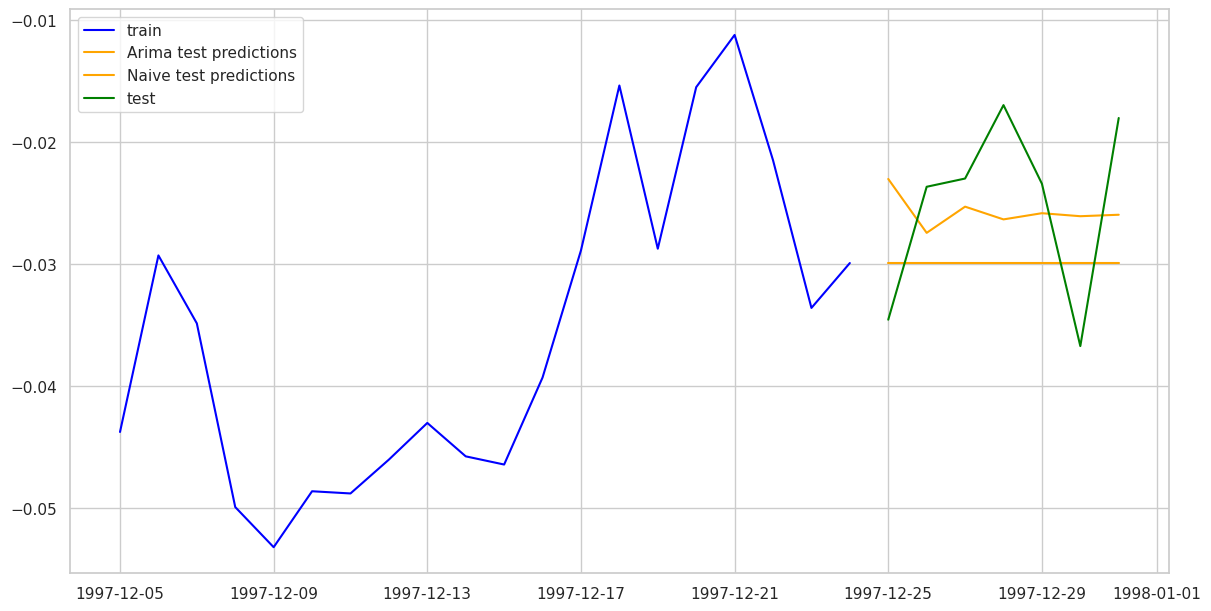

In [93]:
plot_df = y_nx_test.set_index('ds')[['y']].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_nx_train.set_index('ds')['y'].tail(20), label='train', color='blue')
ax.plot(y_models1_pred.set_index('ds')[['arima1']], label=' Arima test predictions', color='orange')
ax.plot(y_models1_pred.set_index('ds')[['naive1']], label=' Naive test predictions', color='orange')
ax.plot(plot_df['y'], label='test', color='green')
ax.legend(["train", "Arima test predictions", "Naive test predictions", "test"])
plt.show();plt.close()

# Forecasting performance of ARIMA models

::: {.callout-note  icon=false}

#### Cross validation scores with ARIMA Models

The major difference between the two libraries is in the prediction step. We will see that in this case the `Nixtla` implementation is easier to use. We will use temporal cross validation to evaluate the model, in the same way we introduced for baseline models. The Nixtla framework makes it easy to work with both models (ARIMA and Naive) in parallel.

:::

We use `cross_validation` to create the folds:

In [94]:
y_cv_df = y_models1.cross_validation(
    df = y_nx_train,
    h = fh,
    step_size = 1,
    n_windows = 10)

In [95]:
y_cv_df.head(12)

,unique_id,ds,cutoff,y,arima1,naive1
0,Y2,1997-12-09,1997-12-08,-0.053,-0.049,-0.050
1,Y2,1997-12-10,1997-12-08,-0.049,-0.041,-0.050
2,Y2,1997-12-11,1997-12-08,-0.049,-0.045,-0.050
3,Y2,1997-12-12,1997-12-08,-0.046,-0.043,-0.050
4,Y2,1997-12-13,1997-12-08,-0.043,-0.044,-0.050
5,Y2,1997-12-14,1997-12-08,-0.046,-0.043,-0.050
6,Y2,1997-12-15,1997-12-08,-0.046,-0.044,-0.050
7,Y2,1997-12-10,1997-12-09,-0.049,-0.044,-0.053
8,Y2,1997-12-11,1997-12-09,-0.049,-0.046,-0.053
9,Y2,1997-12-12,1997-12-09,-0.046,-0.045,-0.053


Now we can simply call evaluate:

In [96]:
from utilsforecast.evaluation import evaluate
y_models1_eval = evaluate(y_cv_df, metrics=[rmse, mape], models=["arima1", "naive1"])
y_models1_eval

,unique_id,cutoff,metric,arima1,naive1
0,Y2,1997-12-08,rmse,0.004,0.004
1,Y2,1997-12-09,rmse,0.003,0.008
2,Y2,1997-12-10,rmse,0.008,0.009
3,Y2,1997-12-11,rmse,0.014,0.015
4,Y2,1997-12-12,rmse,0.016,0.015
5,Y2,1997-12-13,rmse,0.018,0.017
6,Y2,1997-12-14,rmse,0.023,0.023
7,Y2,1997-12-15,rmse,0.024,0.025
8,Y2,1997-12-16,rmse,0.022,0.019
9,Y2,1997-12-17,rmse,0.016,0.010


And we comute the average performance across folds for both models and both metrics:

In [97]:
y_models1_eval.groupby("metric")[['arima1', 'naive1']].mean()

,arima1,naive1
metric,,
mape,0.665,0.627
rmse,0.015,0.015


### Visualizing Cross Validation

Nixtla provides a very nice way of illustrating the result of cross validation for the different folds as follows:

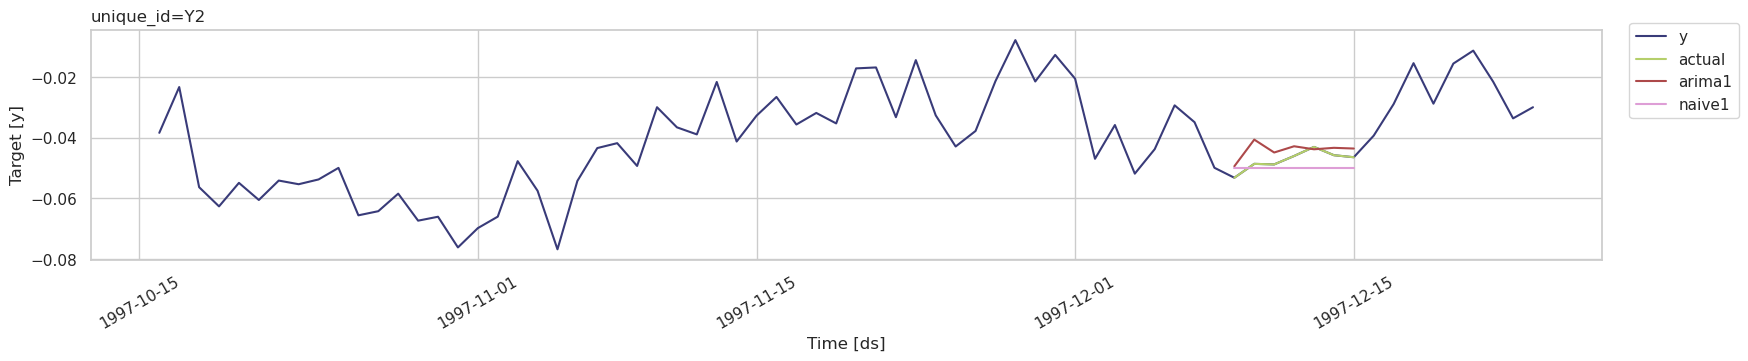

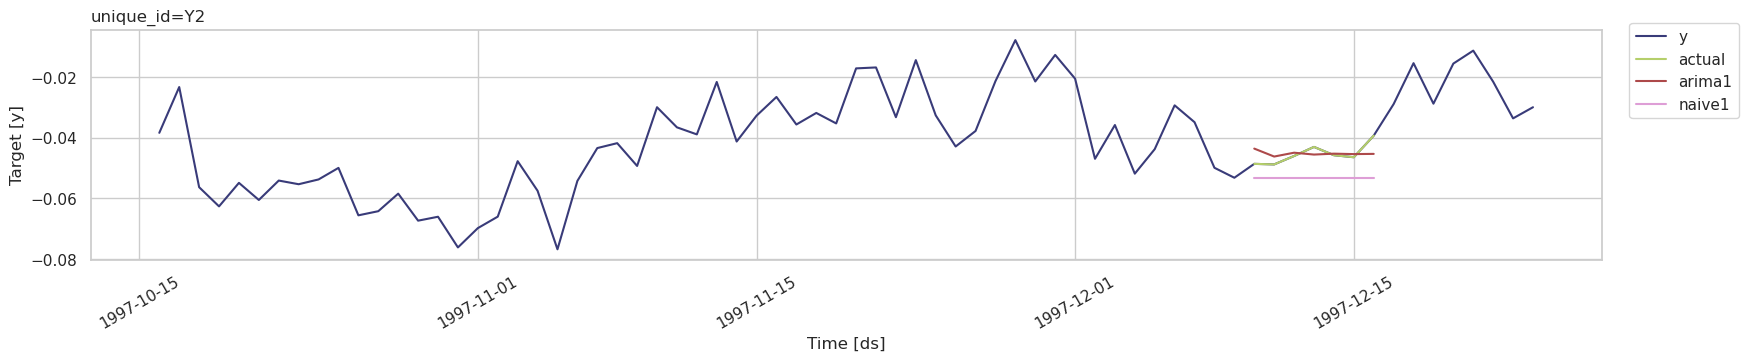

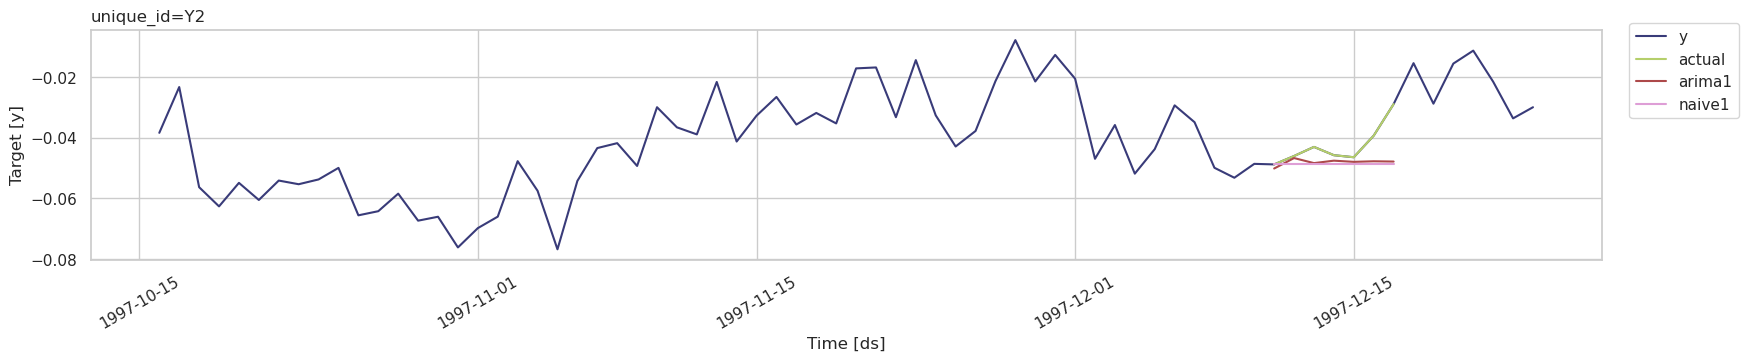

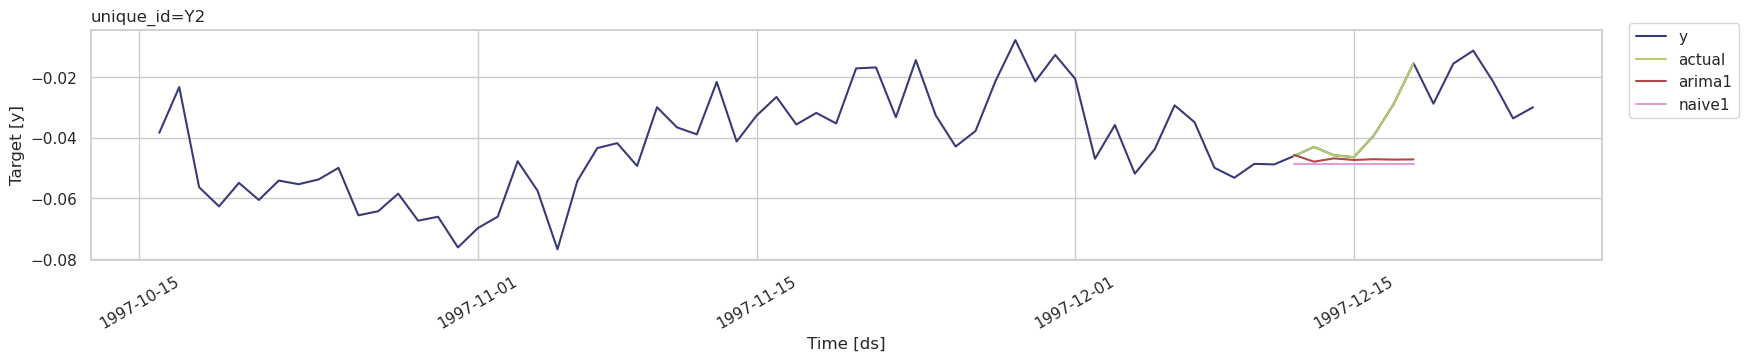

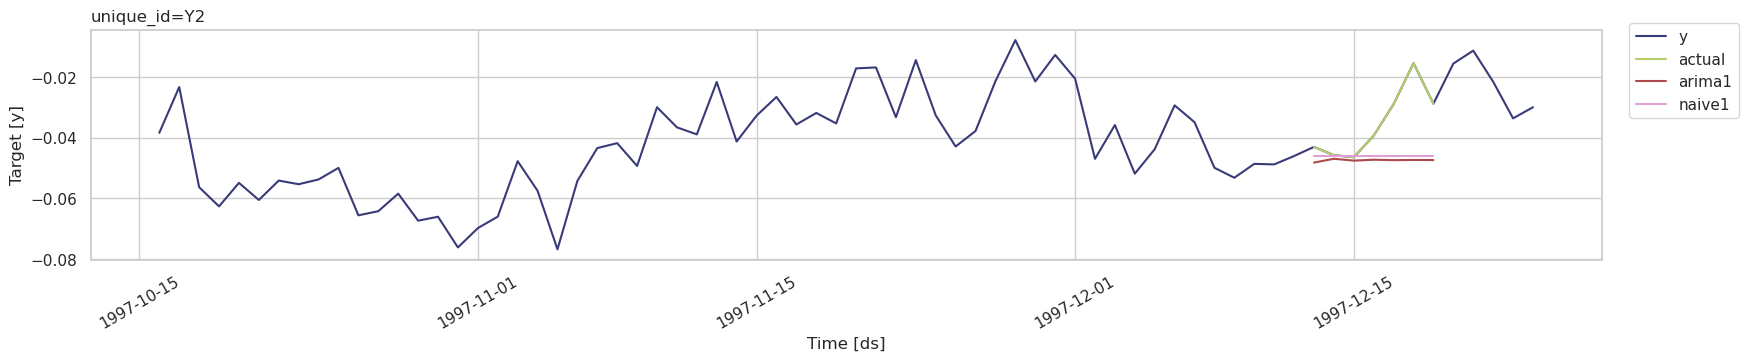

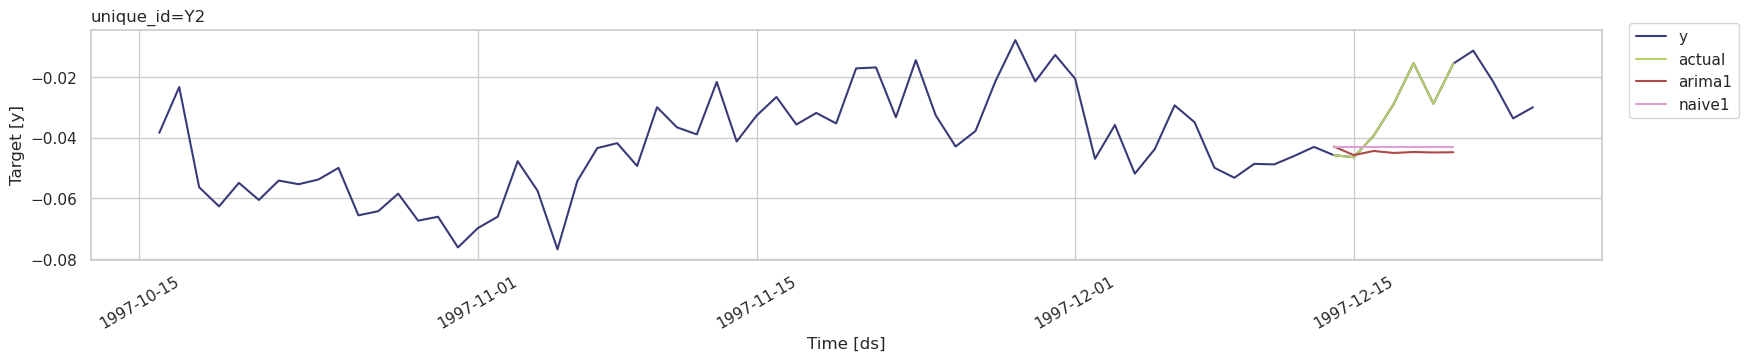

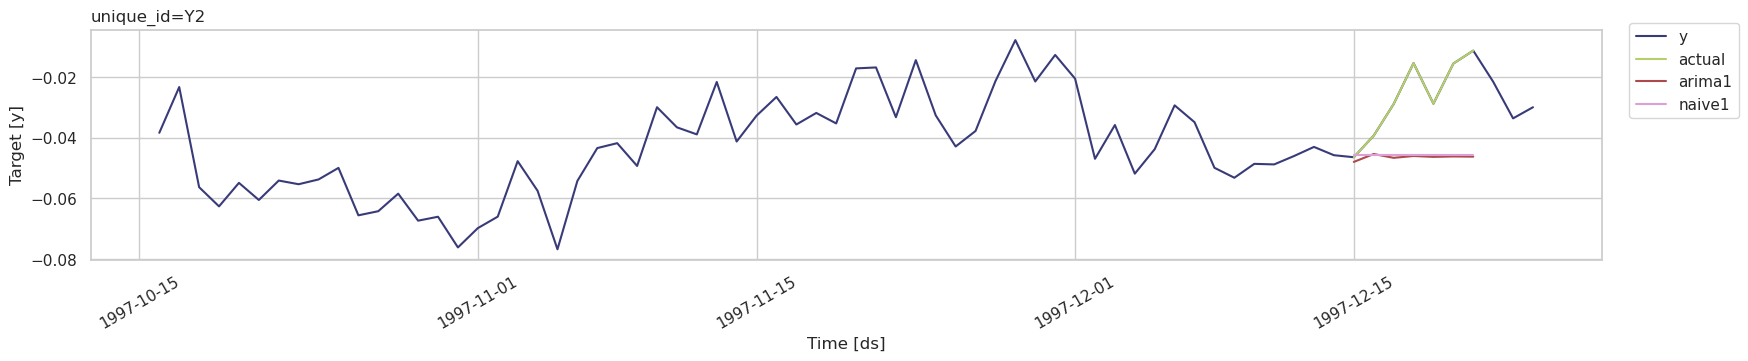

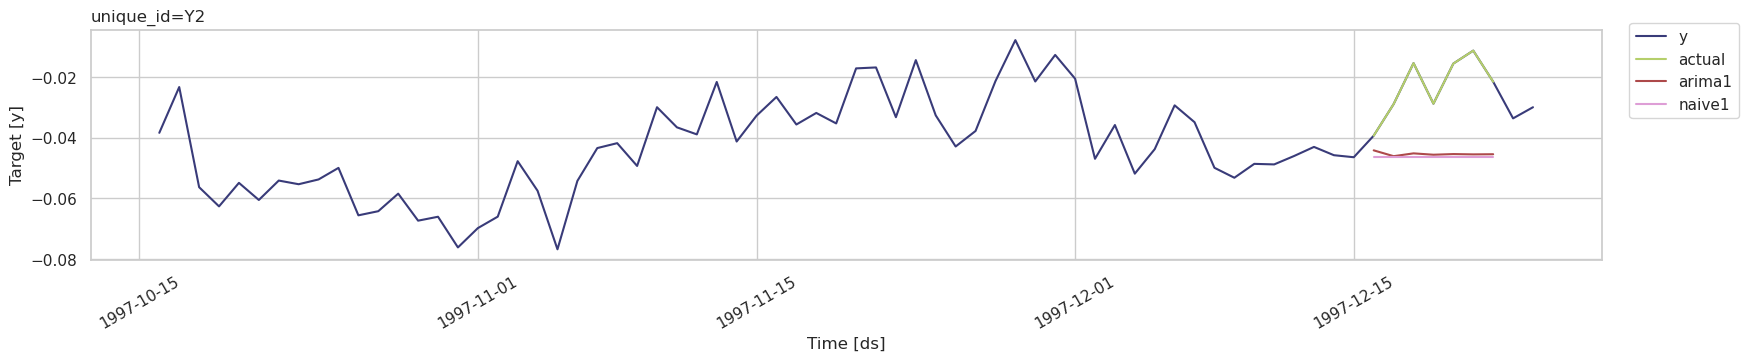

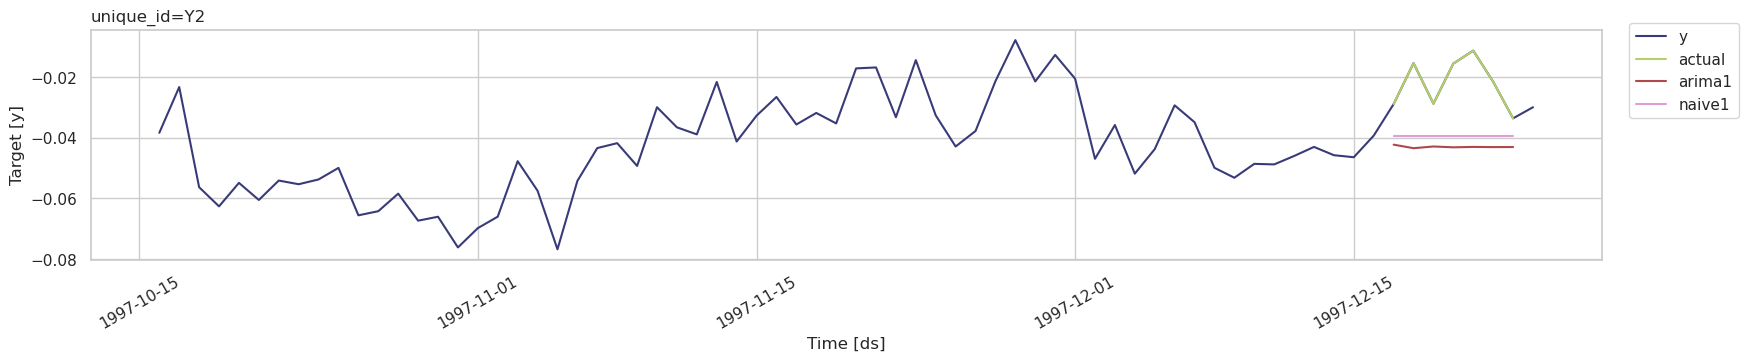

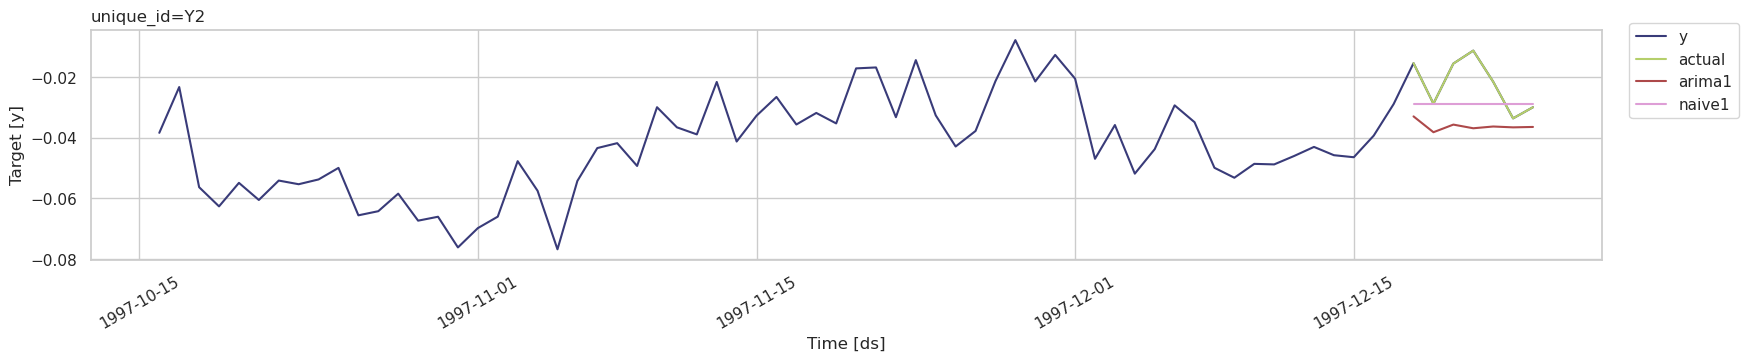

In [98]:
y_cv_plot = y_cv_df.copy()
y_cv_plot.rename(columns = {'y' : 'actual'}, inplace = True) # rename actual values

cutoff = y_cv_plot['cutoff'].unique()

for k in range(len(cutoff)):
    cv = y_cv_plot[y_cv_plot['cutoff'] == cutoff[k]]
    display(StatsForecast.plot(y_nx_train.tail(10 * fh), cv.loc[:, cv.columns != 'cutoff']))

## Test set evaluation for the Nixtla ARIMA model

We achieve this by using 1-fold cross validation with a single window whose length equals the length of the test set (it is equal to the forecasting horizon)

In [99]:
y_cv_df_test = y_models1.cross_validation(
    df = pd.concat([y_nx_train, y_nx_test]),
    h = fh,
    step_size = 1,
    n_windows = 1)

In [100]:
model_list = [_.alias for _ in y_models1.models]
model_list

y_nx_eval_test = evaluate(y_cv_df_test, metrics=[rmse, mape], models=model_list)
y_nx_eval_test

,unique_id,cutoff,metric,arima1,naive1
0,Y2,1997-12-24,rmse,0.008,0.008
1,Y2,1997-12-24,mape,0.283,0.369


______


# Seasonal ARMA Processes

::: {.callout-note  icon=false}

#### Definition of the Seasonal ARMA Processes

A seasonal ARMA process is the natural generalization of the ARMA stochastoc processes we have seen, 

An stochastic process is an **$\textbf{ARMA}(p, q)(P, Q)_s$ process with seasonality $s$** if it satisfies the equation
$$
(1 - \phi_{1}B - \cdots - \phi_{p}B^p)(1 - \Phi_{1}B^s - \Phi_{1}B^{2\,s} - \cdots - \Phi_{p}B^{p \,s})y_{t} =  
(1 - \theta_{1}B - \cdots - \theta_{q}B^q)( 1 - \Theta_{1}B^s  - \Theta_{2}B^{2\, s} - \cdots - \Theta_{q}B^{q\,s})\varepsilon_{t}
$$
where, as usual, $\varepsilon_{t}$ is white noise. The pairs $(p, q)$ and $(P, Q)$ are respectively called the **order** and **seasonal order** of the process. Note that each member of the equation above now contains an additional factor, a polynomial in the **seasonal backshift operator** $B^s$. A time series is called an $\text{ARMA}(p, q)(P, Q)_s$ series if it is a realization of one of these sthocastic processes.

As in the non seasonal case,  the process is stationary and invertible if the roots of the corresonding polynomials are outside the complex unit circle.

:::

::: {.callout-note icon=false}

#### Simulating a Seasonal ARMA Processes

The `generate_sample` method of the [`ArmaProcess` object in statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima_process.ArmaProcess.html) can be used to generate $\text{ARMA}(p, q)(P, Q)_s$ time series. Let us, for example, generate a time series as a realization of 
$$ 
\left(1 - \dfrac{B}{2}\right) \left(1 - \dfrac{B^{12}}{3}\right)y_{t} = 
\left(1 - \dfrac{B}{5}\right)\left(1 - 3 \dfrac{B^{12}}{4}\right)\varepsilon_{t}
$$ 
The steps are similar to the non seasonal case: first we generate a white noise time series. 

:::


In [101]:
sp = 12 
n = 40 * sp

def noise_gen(size, seed=2024):
    rng = np.random.default_rng(seed)
    return rng.normal(size = size)

W = noise_gen(size = n)

Next we define the coefficients of the model using numpy arrays, including both the seasonal and nonseasonal polynomials. 
$$ 
\left(1 - \dfrac{B}{2}\right) \left(1 - \dfrac{B^{12}}{3}\right)y_{t} = 
\left(1 - \dfrac{B}{5}\right)\left(1 - 3 \dfrac{B^{12}}{4}\right)\varepsilon_{t}
$$ 
We need to expand the polynomial products since `generate_sample` does not directly include seasonality: 
$$
\left(\frac{B^{13}}{6} - \frac{B^{12}}{3} - \frac{B}{2} + 1\right)y_{t} = 
\left(3 \dfrac{B^{13}}{20} - 3 \dfrac{B^{12}}{4} - \dfrac{B}{5} + 1\right)\varepsilon_{t}
$$
Recall that the sign of the autoregressive coefficients is reversed:

In [102]:
ar_cff = np.zeros(14)
ar_cff[0]  =    1
ar_cff[1]  = -1/2
ar_cff[12] = -1/3
ar_cff[13] =  1/6

ma_cff = np.zeros(14)
ma_cff[0]  =     1
ma_cff[1]  =  -1/5
ma_cff[12] =  -3/4
ma_cff[13] =   3/20


And now we can call `generate_sample`:

In [103]:
Y_ts = ArmaProcess(ar_cff, ma_cff).generate_sample(nsample=n, distrvs=noise_gen)
Y = "Y"
df_ts = pd.DataFrame({"Y":Y_ts})
df_ts.head()


,Y
0,1.029
1,1.951
2,1.794
3,-0.306
4,-1.351


Let us plot the time series, ACF and PACF. Note that there are significant values both in the first lags, but also around the first multiples of the seasonal period.

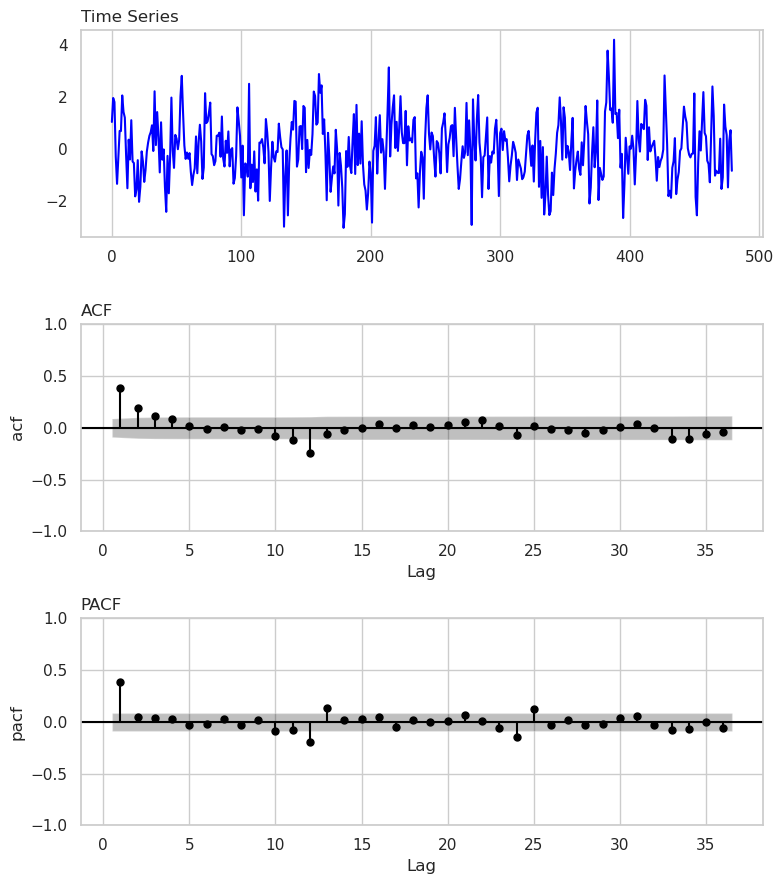

In [104]:
plot_acf_pacf(df_ts=df_ts, var=Y, lags=3 * sp)
plt.show();plt.close()

::: {.callout-note  icon=false}

## Seasonal ACF and PACF. Guidelines for Identification.

Seasonal correlations of period s are evidenced in the ACF and PACF when significative coefficients appear in the multiples of the period s.  
Seasonal time series may require seasonal diferencing to make them appear stationary.

Below we use the ACF and PACF for the identification of the regular and seasonal components of a candidate SARIMA model. In order to fo that we use the following guidelines. 

1. The first coefficients of the ACF and PACF are only affected by the regular component.
2. To identify the seasonal component we only use the ACF and PACF values corresponding to multiples of the seasonl frequency.
4. The ACF of the regular component is replicated at the left side of the seasonal lags.
3. The PACF of the regular component is replicated at the right side of the seasonal lags.

We insist: these are **guidelines**, and in specific examples we will often use them as the starting point of some *trial and error* iterations.


:::

::: {.callout-important icon=false}

##### Seasonal correlation is not seasonality

The time series in the example above is stationary, in particular it has no seasonality. It has, however, strong seasonal correlation. That is, the value of $y_t$ is related to the value of the previous seasonal period $y_{t - s}$, as indicated in the process equation. 

:::

---

# SARIMA (Seasonal ARIMA) Modeling Procedure Example

::: {.callout-note  icon=false}

## SARIMA Models Procedure and Examples

From this point, the rest of the modeling process follows along the lines of the non seasonal case. The two major differences are:

1. We may need to use seasonal differencing alongside regular differencing to bring the time series closer to stationarity. The symbols $d$ and $D$ stand respectively for the number of regular and seasonal differences we apply. 
2. We use the ACF and PACF to identify both the regular $(p, q)$ and seasonal $(P, Q)$ orders of the proposed model. 

The basic idea behind SARIMA modeling is the same: a seasonal ARMA process can be considered as a mathematical transformation where the inputs are white noise time series and the outputs are ARMA time series, the **signal** that we see. In modeling we try to reverse the process and go back to the **noise**: we aim for a model fit such that its residuals (all that is left after the model has extracted the signal) are a white noise time series.

Below we will fit a SARIMA model to the Canadian gas example that we already have met in previous sessions. We will proceed step by step. After completing the exploratory part, leading to the determination of the model structure, we will use the framework provided by sktime to fit the model and evaluate its performance.

:::

::: {.callout-note  icon=false}

#### STEP 0: Load the Data, EDA and Naming Conventions

We load the data and create a dataframe using our usual naming conventions. Remember to set the appropiate time index if it is available as a column in the data.

:::

In [105]:
df_ts = pd.read_csv('../4_1_Introduction_to_Forecasting/tsdata/fpp3/Canadian_gas.csv')

# Set 'Month' as index and set frequency as Month end, required by sktime
df_ts["Month"] = pd.to_datetime(df_ts["Month"], format="%Y %b")
# df_ts["Month"] = df_ts["Month"] + pd.offsets.MonthEnd(0)
df_ts.set_index("Month", inplace=True)
df_ts.index.freq = 'MS'

Y = "Volume"
Y_original = Y
y = df_ts[[Y]]
y


,Volume
Month,
1960-01-01,1.431
1960-02-01,1.306
1960-03-01,1.402
1960-04-01,1.170
1960-05-01,1.116
...,...
2004-10-01,17.827
2004-11-01,17.832
2004-12-01,19.453


Let us again make a copy that we will use later on with Nixtla's libraries.

In [106]:
df_nx = df_ts.copy()

::: {.callout-note  icon=false}

#### Setting the Seasonal Period and EDA Plots

We already know this series and we know that it is seasonal with period 12 (it is monthly data after all). So let us set that value right away. 

:::

In [107]:
sp = 12 

fh = 2 * sp

We do the train/tes split function as in the non seasonal part of the session.

In [108]:
y_train = df_ts.iloc[:-fh]
y_test = df_ts.iloc[-fh:]

In [109]:
y_train.tail()

,Volume
Month,
2002-10-01,18.112
2002-11-01,18.135
2002-12-01,19.130
2003-01-01,19.235
2003-02-01,17.246


In [110]:
y_test.head()

,Volume
Month,
2003-03-01,18.413
2003-04-01,17.447
2003-05-01,17.560
2003-06-01,16.848
2003-07-01,17.384


In [111]:
y_train.shape, y_test.shape

((518, 1), (24, 1))

It is always a good practice to visually check the split.

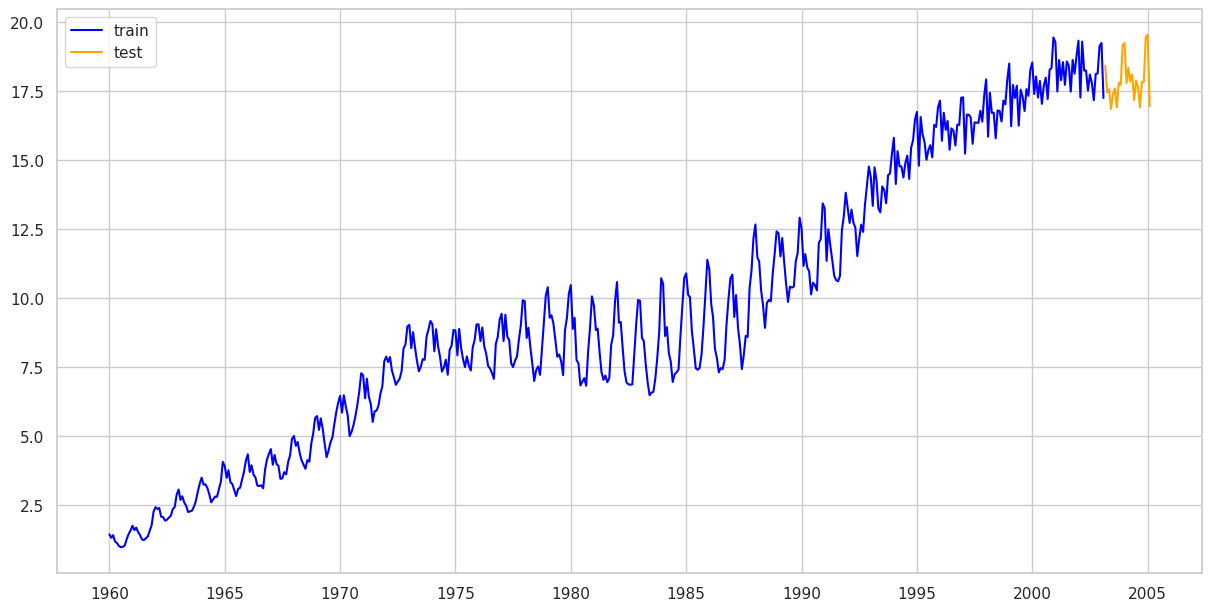

In [112]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_train[Y], label='train', color='blue')
ax.plot(y_test[Y], label='test', color='orange')
ax.legend(["train", "test"])
plt.show();plt.close()


::: {.callout-note  icon=false}

#### Stabilizing the Variance. Box-Cox Transformations.

We already know from the plots above that the variance of the series depends on time (An the Breusch-Pagan test below will point in the same direction. 

:::

In [113]:
y_bxcx = y_train.reset_index(drop=True).reset_index()
y_bxcx.columns = ['time', 'value']
y_bxcx
formula = 'value ~ time'
olsr = ols(formula, y_bxcx).fit()

_, breusch_pagan_p_value, _, _ = sms.het_breuschpagan(olsr.resid, olsr.model.exog)
breusch_pagan_p_value 

np.float64(1.2977662520522487e-06)

The p-value is very low, so we can reject the null hypothesis of homoscedasticity. We will therefore apply the Box-Cox transformation to the series. In case you decide not to use it you can simply switch `box_cox = false` in the next cell.

For the identification of the model structure We will use a copy of the original train data called `y_train_EDA` to keep the original values unchanged. The final model will be a pipeline that will include all the necessary transformations and the final model.

In [114]:
from coreforecast.scalers import boxcox, boxcox_lambda

y_train_lambda = boxcox_lambda(y_train[Y], method='guerrero', season_length=1)
y_train_lambda

1.9916213750839233

Not using Box-Cox transformation.
The Y variable now is: Volume


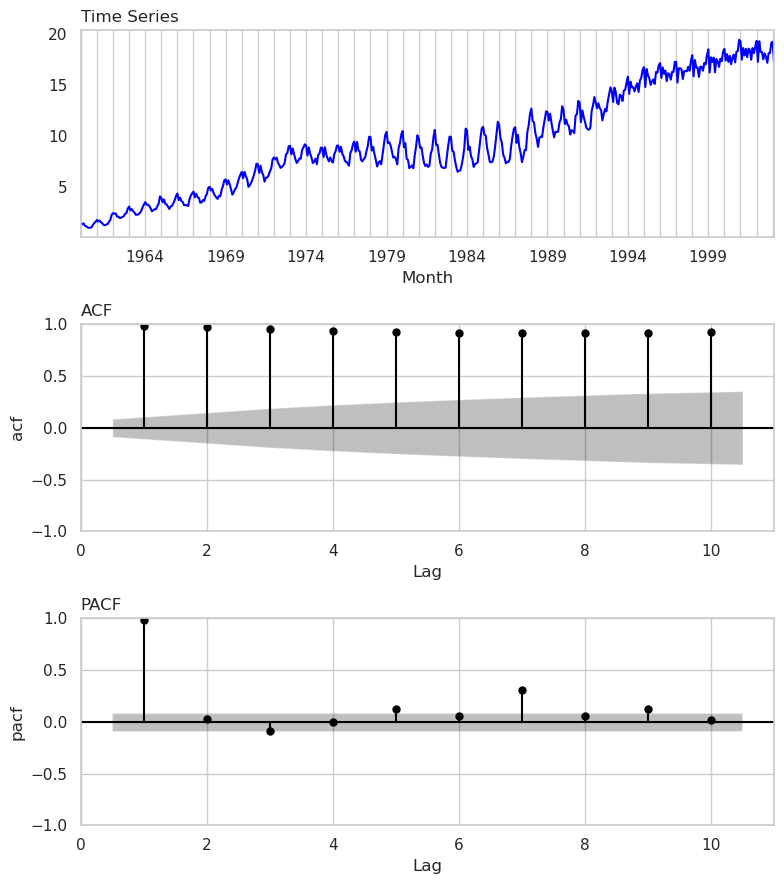

In [115]:
use_boxcox = False

if use_boxcox:
    y_train_original = y_train.copy()
    transformed_y_train = boxcox(y_train[[Y]], lmbda=y_train_lambda)
    Y_original = Y
    Y = Y + "_bxcx"
    y_train[Y] = transformed_y_train
    print("Using Box-Cox transformation with lambda =", y_train_lambda)
else:
    print("Not using Box-Cox transformation.")

print(f"The Y variable now is: {Y}")

plot_acf_pacf(df_ts=y_train, var=Y)

As it is often the case, the Box-Cox transformation has not completely stabilized the variance. We can see that the variance is still dependent on time, but we will move on just remembering that this may interfere with our models' estimations. 

---

::: {.callout-note  icon=false}

#### Deciding if Differencing is Required 

The above time plot clearly still shows a trend and seasonality, and the ACF confirms that the series is not stationary. We will therefore apply both seasonal and regular differencing to the series. 

We will also use `ndiffs` from the `pmdarima` library to determine the number of differences required to make the series stationary.

:::

::: {.callout-warning  icon=false}

#### Ordering of Seasonal and Regular Differencing

We have already discussed this but recall that **if seasonal differencing is to be applied, it should always come before regular differencing.** 

:::

In [116]:
D = nsdiffs(y_train[Y], m = sp)
d = ndiffs(y_train[Y])
print(f"Number of suggested seasonal differences = {D}")   
print(f"Number of suggested regular differences = {d}")   


Number of suggested seasonal differences = 0
Number of suggested regular differences = 1


::: {.callout-warning  icon=false}

#### Do Not Mindlessly Rely on Automatic Procedures!

Use your judgement as data analyst and make educated decisions, even when automated procedures seel seem to suggest otherwise! Here we get 0 as suggested value of $D$, the number of seasonal differences needed. But even if the result suggests $D = 0$, the presence of seasonality is obvious in the time plot. So in any case we would manually set $D$ to 1 and apply the seasonal difference. 

:::

In [117]:
D = 1

if (D > 0):
    y_train["Y_diff"] = y_train[Y].diff(periods = D * sp)
    Ydiff = "Y_diff"
else:
    Ydiff = Y
    
print(f"Number of applied seasonal differences = {D}")       

Number of applied seasonal differences = 1


In [118]:
y_train

,Volume,Y_diff
Month,,
1960-01-01,1.431,NaN
1960-02-01,1.306,NaN
1960-03-01,1.402,NaN
1960-04-01,1.170,NaN
1960-05-01,1.116,NaN
...,...,...
2002-10-01,18.112,-0.510
2002-11-01,18.135,0.011
2002-12-01,19.130,0.378


::: {.callout-note  icon=false}

#### Caveats about Differencing

Note that: 
+ If necessary, we update the name `Y` to point to the seasonally differenced series.
+ Seasonal differencing will create as many missing initial values in the series as the seasonal frequency.

:::

#### Checks for Stationarity

After seasonal differencing we check again for stationarity, both visually and with the ADF test. Note the almost linear decay of the ACF, which is a sign of non stationarity.

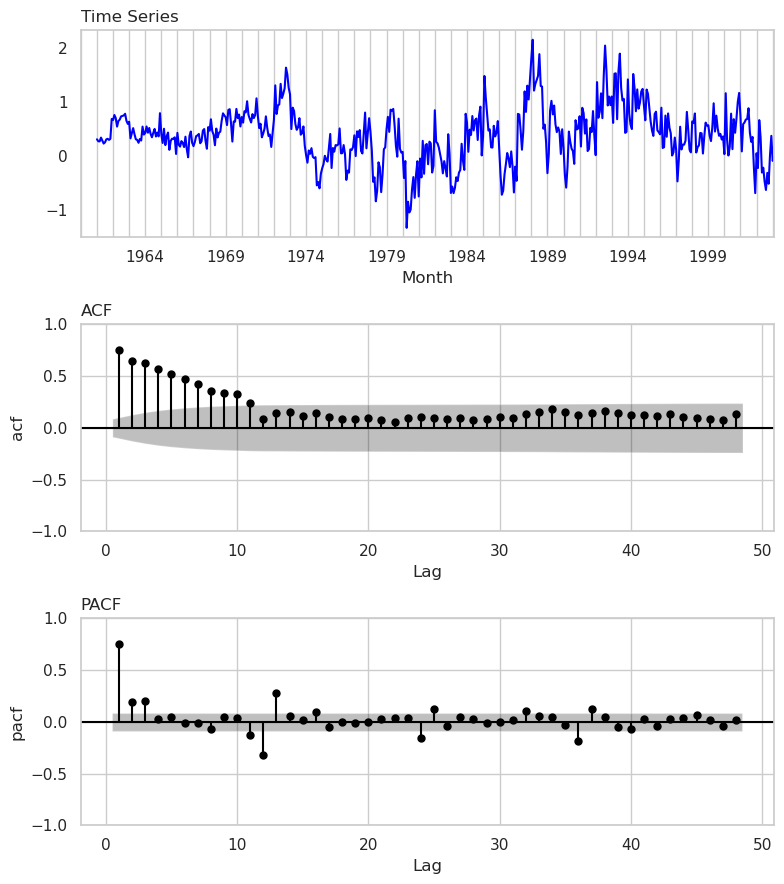

In [119]:
plot_acf_pacf(df_ts=y_train, var=Ydiff, lags= 4 * sp)
plt.show();plt.close()

Note the use of `dropna` below:

In [120]:
ADF_pvalue = adfuller(y_train[Ydiff].dropna())[1]
print(f"The ADF p-value is {ADF_pvalue}, the null hypothesis of non-stationarity is {'rejected' if ADF_pvalue < 0.05 else 'not rejected'}")
KPSS_pvalue = kpss(y_train[Ydiff].dropna())[1]
print(f"The KPSS p-value is {KPSS_pvalue}")

The ADF p-value is 0.014474422192965415, the null hypothesis of non-stationarity is rejected
The KPSS p-value is 0.1


Meanwhile, the result of applying `ndiffs` (that uses a different test of stationarity) to the (already seasonally differenced) time series is:

In [121]:
d = ndiffs(y_train[Ydiff].dropna())
d

0

#### Regular Differencing

This is yet another opportunity to use our judgement: whatever the result of the ADF and KPSS tests, look at the almost linear decay in the values of the ACF. We will therefore apply a regular difference.

In [122]:
d = 1

if (d > 0) :
    y_train["Y_diff"] = y_train[Ydiff].diff(periods = d)
    Ydiff = "Y_diff"


print(f"Number of applied seasonal differences = {D}")   
print(f"Number of applied regular differences = {d}")   
    
    

Number of applied seasonal differences = 1
Number of applied regular differences = 1


Now the plots and all of our checks indicate that the time series looks stationary (but with the unresolved problem of the variance depending on time):

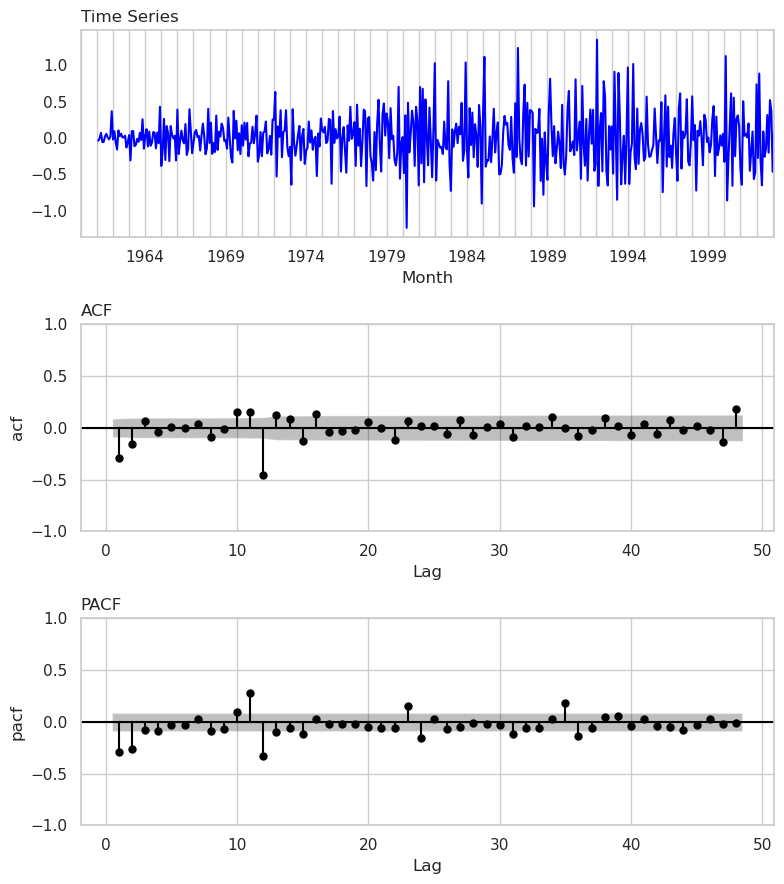

In [123]:
plot_acf_pacf(df_ts=y_train, var=Ydiff, lags= 4 * sp)
plt.show();plt.close()  

And the formal checks:

In [124]:
D_check = nsdiffs(y_train[Ydiff].dropna(), m = sp)
d_check = ndiffs(y_train[Ydiff].dropna())
print(f"Number of suggested seasonal differences = {D_check}")   
print(f"Number of suggested regular differences = {d_check}")   
ADF_pvalue = adfuller(y_train[Ydiff].dropna())[1]
print(f"The ADF p-value is {ADF_pvalue}")
KPSS_pvalue = kpss(y_train[Ydiff].dropna())[1]
print(f"The KPSS p-value is {KPSS_pvalue}")


Number of suggested seasonal differences = 0
Number of suggested regular differences = 0
The ADF p-value is 1.1441852859734683e-13
The KPSS p-value is 0.1


---

::: {.callout-note  icon=false}

#### Identify the Seasonal and Regular Components of the Model

At this point we already have:

1. Decided if we need to apply a Box-Cox or similar  transformation to stabilize the variance.
2. Selected the values of $d$ and $D$, the number of regular and seasonal differences that we eill apply. These correspond to the $I$ part of the S-AR-I-MA model. 

Therefore we proceed to the determination of the (regular) p, q and (seasonal) P, Q orders of the model. We do this using the ACF and PACF of the differenced time series in the training set to identify the seasonal component of the time series. For your convenience we repeat the plot here. And we have added dashed vertical red lines to help you **focus on the seasonal frequency multiples**.

:::

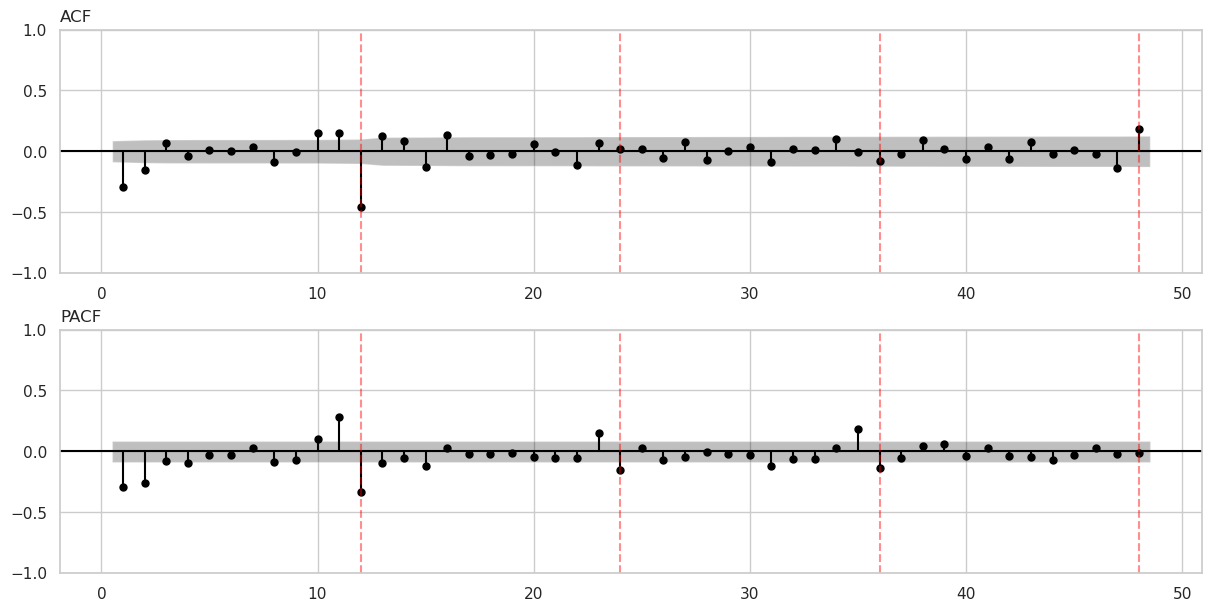

In [125]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
xcoords = [i * sp for i in range(1, 5)]

sm.graphics.tsa.plot_acf(y_train[Ydiff].dropna(), ax=ax[0], lags=4 * sp, zero=False, title='ACF')
for xc in xcoords:
    ax[0].axvline(x=xc, color='red', linestyle='--', alpha=0.25)
    ax[0].axvline(x=xc, color='red', linestyle='--', alpha=0.25)
sm.graphics.tsa.plot_pacf(y_train[Ydiff].dropna(), ax=ax[1], lags=4 * sp, zero=False, title='PACF')
for xc in xcoords:
    ax[1].axvline(x=xc, color='red', linestyle='--', alpha=0.25)
    ax[1].axvline(x=xc, color='red', linestyle='--', alpha=0.25)
plt.show();plt.close()


As a result we propose the following $(P, Q)$ order for the seasonal component of the model:

In [126]:
P = 0
Q = 1

As we mentioned before, setting these values is often a trial and error process. We will come back below to this idea of exploring different combinations of orders. 

#### Regular Component

To identify the regular component of the model we use again  the ACF and PACF of the differenced time series but this time  **we focus on the first values of the ACF and PACF before the seasonal frequency**. This is illustrated by the shaded area in the ACF and PACF below. 

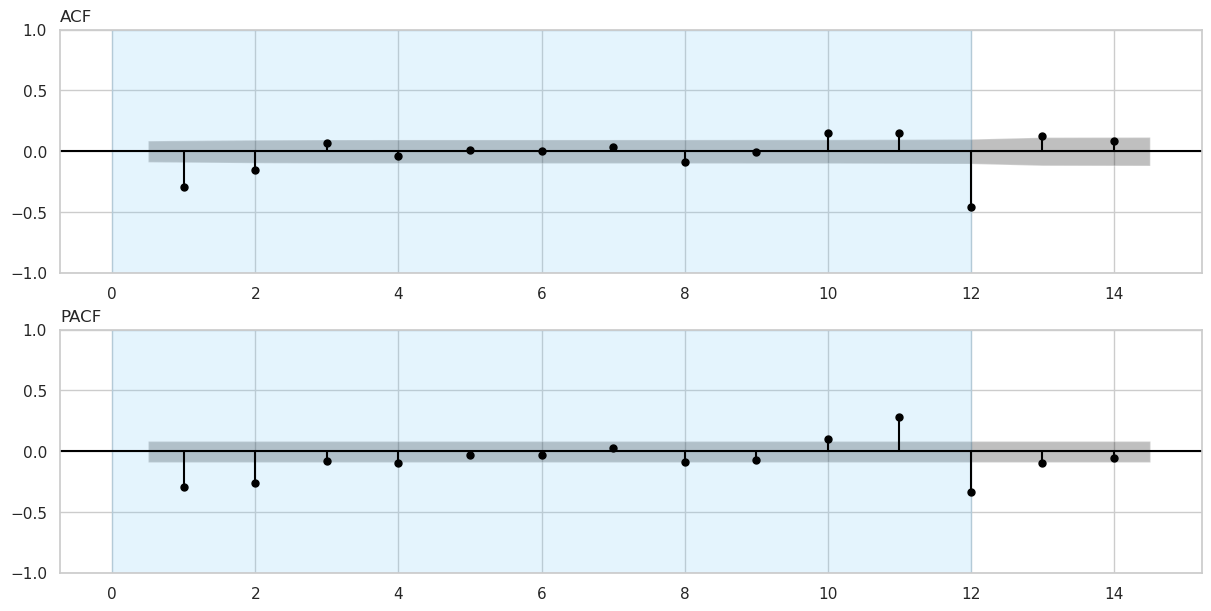

In [127]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

sm.graphics.tsa.plot_acf(y_train[Ydiff].dropna(), ax=ax[0], lags= 1.2 * sp , zero=False, title='ACF')
ax[0].axvspan(0, sp, color='#7BC8F6', alpha=0.2)

sm.graphics.tsa.plot_pacf(y_train[Ydiff].dropna(), ax=ax[1], lags= 1.2 * sp, zero=False, title='PACF')
ax[1].axvspan(0, sp, color='#7BC8F6', alpha=0.2)

plt.show();plt.close()


The pattern in these values suggests that  AR and MA may both be present. So  we can try an initial guess such as the following:

In [128]:
p = 1
q = 1

<h1 style="color:firebrick">SARIMA (Seasonal ARIMA) model fit with Statsmodels</h1>

::: {.callout-note  icon=false}

#### Fitting an ARIMA Model the statsmodels way

*Note:* this was our *only* method for the previous year. We keep it here because the alternative is still experimental for us, and also because it is probably the most common way to fit ARIMA models in Python.

Now we pass those values to the ARIMA function from the statsmodels library (we call it smARIMA because we will soon use another version) and we use the `fit` method to estimate the parameters of the model. Note that, contrary to sklearn, the data is not passed to the `fit` method, but to the `endog` parameter of the ARIMA object. Note also that we pass the non-differenced series to the `fit` method, as the ARIMA object will take care of the differencing.

:::

In [129]:
if use_boxcox:
    print("Fitting ARIMA model on Box-Cox transformed data with lambda =", y_train_lambda)
else:
    y_nx_train = y_nx_train_original.copy()

In [130]:
p, d, q, P, D, Q, sp, y_nx_train_lambda

(1, 1, 1, 0, 1, 1, 12, 1.9916213750839233)

In [131]:
if (d + D > 0):
    print("Including a constant term in the ARIMA model to account for differencing.")
    trend = "n"
else:
    trend = "t"


arima_model = smARIMA(endog = y_train[Y], order=(p, 1, q), trend=trend, seasonal_order=(P, D, Q, sp)).fit() 
model_name = "ARIMA_" + str(p) + "_" + str(d) + "_" + str(q)

Including a constant term in the ARIMA model to account for differencing.


### Statsmodels SARIMA model diagnosis

::: {.callout-note  icon=false}

#### SARIMA Model Diagnosis. Step 1: significance of the coefficients (and possible refitting).

Next we check if the coefficients of this model are statistically significant

:::


In [132]:
print(arima_model.summary())

                                    SARIMAX Results                                     
Dep. Variable:                           Volume   No. Observations:                  518
Model:             ARIMA(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -82.334
Date:                          Wed, 25 Mar 2026   AIC                            172.669
Time:                                  13:22:38   BIC                            189.567
Sample:                              01-01-1960   HQIC                           179.297
                                   - 02-01-2003                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4402      0.081      5.420      0.000       0.281       0.599
ma.L1         -0.7559      0.059    -12.787      0.


Now all the coefficients of the model are significant. 

::: {.callout-note  icon=false}

#### SARIMA Model Diagnosis. Step 2:  Residuals analysis.

Now we inspect the model's residuals to see if the qualify as Gaussian White Noise. We will draw some diagnostic plots and apply the Ljung-Box test to the residuals.

:::

First we extract the residuals:

In [133]:
residuals = arima_model.resid[d:]
resid_df = pd.DataFrame({'residuals':residuals})

The residual plots below show:

1. The residuals ACF show not very significantly different from zero coefficients. This is a good sign that the residuals are white noise. Some values are slightly above the significance threshold, but that is to be expected in real world data, and it is not a cause of deep concern about the model. Keep in mind that ARIMA family models are linear, and in the event of non linearity in pur data they might struggle to obtain good results.
2. The residuals histogram shows a distribution that is close to normal. This is another good sign.
3. The Q-Q plot shows that the residuals do not completely behave like the normal distribution, there is some hint of heteroskedasticity. 
4. The time plot of the standardized residuals points in the same direction, the variance is not completely homogeneous.

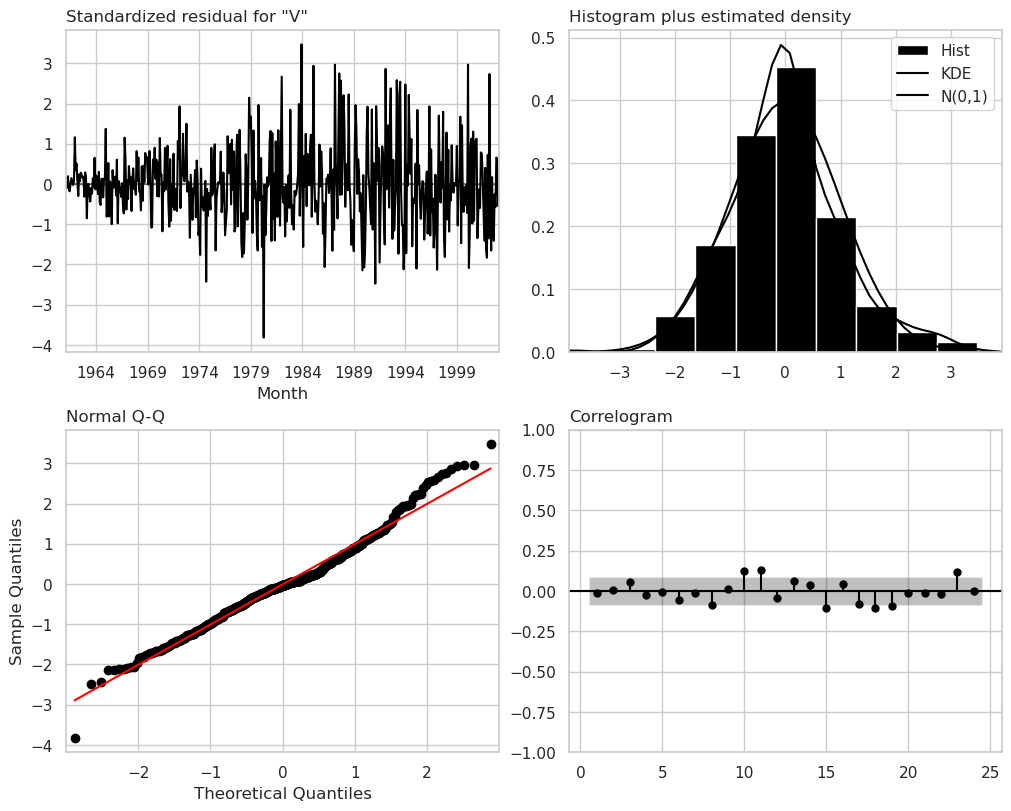

In [134]:
arima_model.plot_diagnostics(figsize=(10, 8), acf_kwargs={'zero':False}, lags= 2 * sp);
plt.show();plt.close()

Let us also compute the Ljung-Box statistics using the first lags of the residuals, including at least the first seasonal lags. 

In [135]:
sm.stats.acorr_ljungbox(residuals, lags=np.arange(1, 2 * sp, 1))

,lb_stat,lb_pvalue
1,0.051,8.218e-01
2,0.073,9.639e-01
3,1.298,7.296e-01
4,1.676,7.951e-01
5,1.713,8.873e-01
6,3.572,7.343e-01
7,3.656,8.185e-01
8,7.855,4.478e-01
9,7.942,5.400e-01
10,15.962,1.007e-01


The results are in line with our comments for the residual plots. These are not perfect, but they are within a tolerable margin.

#### Visualizing predicted vs real

In this example we are not using Box-Cox, but keep in mind the warning about scaled data.

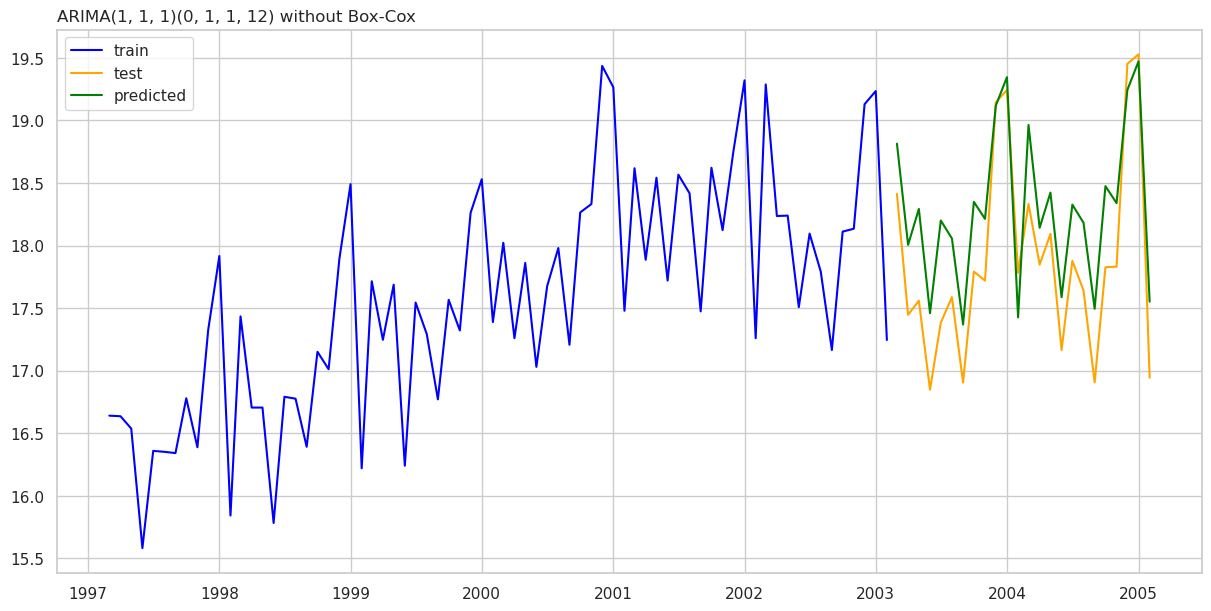

In [136]:
plot_df = y_test.copy()
if use_boxcox:
    plot_df[Y_original] = boxcox(plot_df[Y_original], lmbda=y_train_lambda)

y_nx_test_pred = arima_model.predict(start=y_test.index[0], end=y_test.index[-1])


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_train[Y_original].tail(3 * fh), label='train', color  = "blue")
ax.plot(plot_df[Y_original], label='test', color='orange')
ax.plot(y_nx_test_pred, label='predicted', color = "green")
ax.legend(["train", "test", "predicted"])
if use_boxcox:
    ax.set_title(f"ARIMA({p}, {d}, {q})({P}, {D}, {Q}, {sp}) with Box-Cox (lambda={y_train_lambda:.2f})")
else:
    ax.set_title(f"ARIMA({p}, {d}, {q})({P}, {D}, {Q}, {sp}) without Box-Cox")
plt.show();plt.close()  

### Performance metrics for the test set using ARIMA from Statsmodels

We compute the RMSE and MAPE using their definitions. **See the warning above about the scale.**

In [137]:
test_rmse = np.sqrt(np.mean((y_test[Y] - y_nx_test_pred)**2))
test_mape = np.mean(np.abs((y_test[Y] - y_nx_test_pred) / y_test[Y])) * 100

print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAPE: {test_mape:.3f}")
if use_boxcox:
    print(f"Note: The test RMSE and MAPE are calculated on the Box-Cox transformed scale.")

# test_mape = mape(y_test.values, test_pred)

Test RMSE: 0.495
Test MAPE: 2.573


<h1 style="color:firebrick">SARIMA (Seasonal ARIMA) model fit with NIXTLA</h1>

We will now describe an independent processing model fit using Nixtla libraries. Let us begin by preparing the data. Recall that we had already created a copy of the time series for this purpose.

In [138]:
df_nx.head()

,Volume
Month,
1960-01-01,1.431
1960-02-01,1.306
1960-03-01,1.402
1960-04-01,1.170
1960-05-01,1.116


We change columns names and set the index according to Nixtla format:

In [139]:
df_nx = df_nx.reset_index(drop=False).rename(columns={"Month":"ds", "Volume":"y"})
df_nx["unique_id"] = "y"

In [140]:
df_nx.head()

,ds,y,unique_id
0,1960-01-01,1.431,y
1,1960-02-01,1.306,y
2,1960-03-01,1.402,y
3,1960-04-01,1.170,y
4,1960-05-01,1.116,y


And we make the train/test split using the forecasting horizon. Here it is already set; if it were not, remember  to set it in the first line of the code cell below.

In [141]:
fh = fh

y_nx_train = df_nx.iloc[:-fh]
y_nx_test = df_nx.iloc[-fh:]

We check the split and visualize it:

In [142]:
y_nx_train.tail() 

,ds,y,unique_id
513,2002-10-01,18.112,y
514,2002-11-01,18.135,y
515,2002-12-01,19.130,y
516,2003-01-01,19.235,y
517,2003-02-01,17.246,y


In [143]:
y_nx_test.head()

,ds,y,unique_id
518,2003-03-01,18.413,y
519,2003-04-01,17.447,y
520,2003-05-01,17.560,y
521,2003-06-01,16.848,y
522,2003-07-01,17.384,y


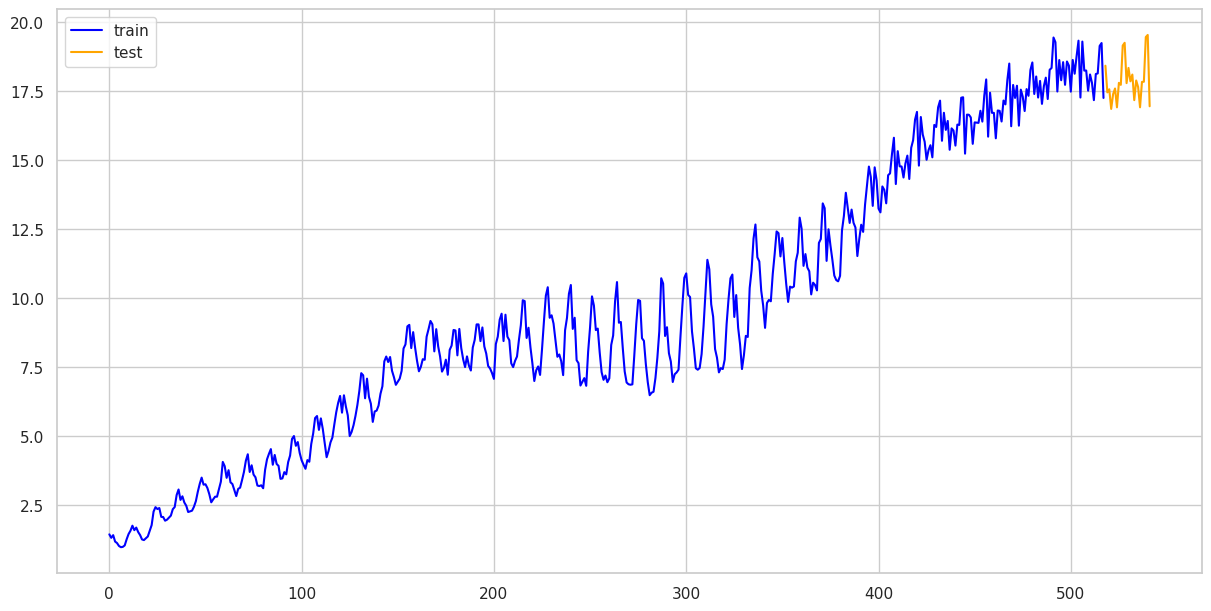

In [144]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_nx_train['y'], label='train', color='blue')
ax.plot(y_nx_test['y'], label='test', color='orange')
ax.legend(["train", "test"])
plt.show();plt.close()

### Stabilizing the variance 

Again, this has already been done above, but for the sake of Nixtla-completeness we repeat the process:

In [145]:
y_bxcx = y_nx_train.drop(columns=["unique_id", "ds"]).reset_index()

y_bxcx.columns = ['time', 'value']
y_bxcx
formula = 'value ~ time'
olsr = ols(formula, y_bxcx).fit()

_, breusch_pagan_p_value, _, _ = sms.het_breuschpagan(olsr.resid, olsr.model.exog)
breusch_pagan_p_value 

np.float64(1.2977662520522487e-06)

The p-value is very low, so we can reject the null hypothesis of homoscedasticity. We will therefore apply the Box-Cox transformation to the series. In case you decide not to use it you can simply switch `box_cox = false` in the next cell.

In [146]:
from coreforecast.scalers import boxcox, boxcox_lambda

y_nx_train_lambda = boxcox_lambda(y_nx_train['y'], method='guerrero', season_length=1)
y_nx_train_lambda

1.9916213750839233

In any case this is a reminder of our previous decision:

In [147]:
if use_boxcox:
    print("Previously we decided to use Box-Cox transformation with lambda =", y_train_lambda)
else:
    print("Previously we decided not to use Box-Cox transformation.")

Previously we decided not to use Box-Cox transformation.


If you want to decide it here, uncomment and use the first code line below:

In [148]:
# use_boxcox = False

if use_boxcox:
    y_nx_train_original = y_nx_train.copy()
    transformed_y_train = boxcox(y_nx_train[['y']], lmbda=y_train_lambda)
    y_nx_train['y'] = transformed_y_train
    print("Using Box-Cox transformation with lambda =", y_train_lambda)
else:
    print("Not using Box-Cox transformation.")    


Not using Box-Cox transformation.


#### Deciding about Differencing and choosing the ARMA structure 


::: {.callout-warning  icon=false}

#### Ordering of Seasonal and Regular Differencing

We have already discussed this but recall that **if seasonal differencing is to be applied, it should always come before regular differencing.** 

:::

In [149]:
from coreforecast.differences import num_seas_diffs, num_diffs

D = num_seas_diffs(y_nx_train['y'], season_length=sp)
d = ndiffs(y_nx_train['y'])


print(f"Number of suggested seasonal differences = {D}")   
print(f"Number of suggested regular differences = {d}")   


Number of suggested seasonal differences = 1
Number of suggested regular differences = 1


::: {.callout-warning  icon=false}

#### Be careful with automatic procedures!

Note that here we are using a different version, this one is from Nixtla, while ndiffs and nsdiffs belong to pmdarima (another forecasting library). 

:::

We are making a copy of the data for this exploratory part of the analysis:

In [150]:
D = 1

y_nx_train_EDA = y_nx_train.copy()

if (D > 0):
    y_nx_train_EDA["y"] = y_nx_train_EDA["y"].diff(periods = D * sp)
    
print(f"Number of applied seasonal differences = {D}")       

Number of applied seasonal differences = 1


#### Checks for Stationarity

After seasonal differencing we check again for stationarity, both visually and with the ADF test. Note the almost linear decay of the ACF, which is a sign of non stationarity.

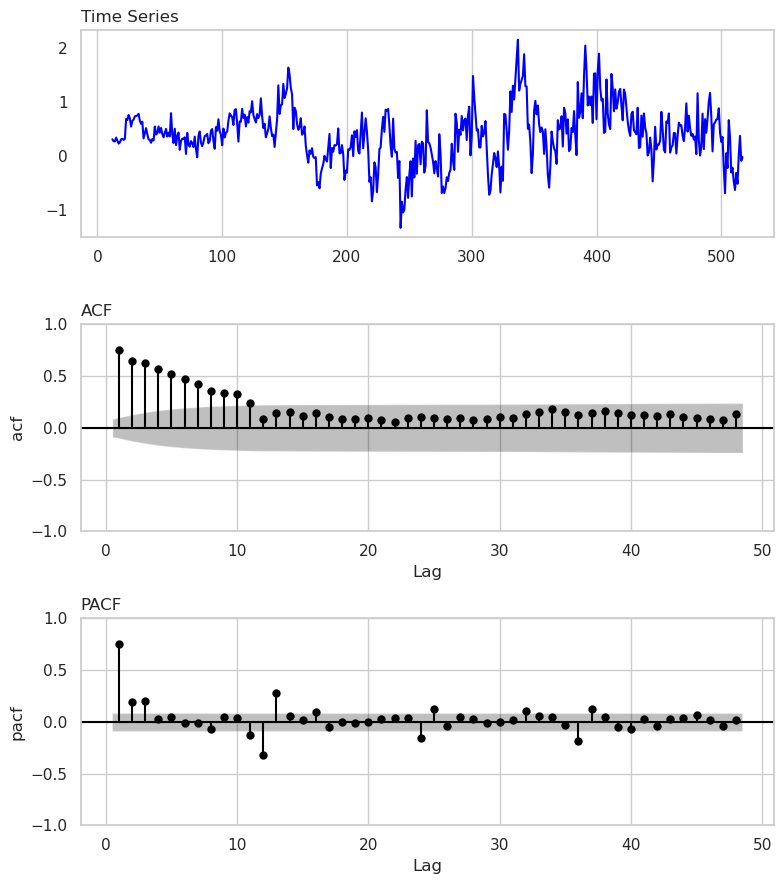

In [151]:
plot_acf_pacf(df_ts=y_nx_train_EDA, var='y', lags= 4 * sp)
plt.show();plt.close()

Formal checks:

In [152]:
ADF_pvalue = adfuller(y_nx_train_EDA['y'].dropna())[1]
print(f"The ADF p-value is {ADF_pvalue}, the null hypothesis of non-stationarity is {'rejected' if ADF_pvalue < 0.05 else 'not rejected'}")
KPSS_pvalue = kpss(y_nx_train_EDA['y'].dropna())[1]
print(f"The KPSS p-value is {KPSS_pvalue}, the null hypothesis of stationarity is {'rejected' if KPSS_pvalue < 0.05 else 'not rejected'}")

The ADF p-value is 0.014474422192965415, the null hypothesis of non-stationarity is rejected
The KPSS p-value is 0.1, the null hypothesis of stationarity is not rejected


Next we apply the Nixtla version for regular differencing called `num_diffs`:

In [153]:
d = num_diffs(y_nx_train_EDA['y'].dropna())
d

0

#### Regular Differencing

Even with the above results, look at the almost linear decay in the values of the ACF. We will therefore apply a regular difference.

In [154]:
d = 1

if (d > 0) :
    y_nx_train_EDA["y"] = y_nx_train_EDA["y"].diff(periods = d)


print(f"Number of applied seasonal differences = {D}")   
print(f"Number of applied regular differences = {d}")   
    
    

Number of applied seasonal differences = 1
Number of applied regular differences = 1


Now the plots and all of our checks indicate that the time series looks stationary (but with the unresolved problem of the variance depending on time):

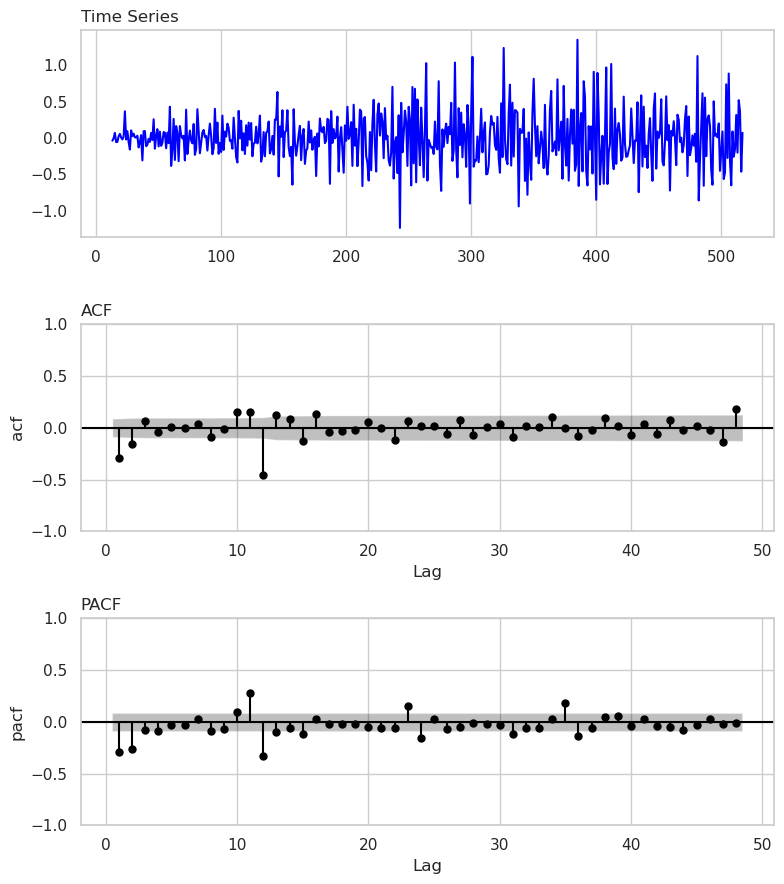

In [155]:
plot_acf_pacf(df_ts=y_nx_train_EDA, var='y', lags= 4 * sp)
plt.show();plt.close()  

And the formal checks:

In [156]:
ADF_pvalue = adfuller(y_nx_train_EDA['y'].dropna())[1]
print(f"The ADF p-value is {ADF_pvalue}, the null hypothesis of non-stationarity is {'rejected' if ADF_pvalue < 0.05 else 'not rejected'}")
KPSS_pvalue = kpss(y_nx_train_EDA['y'].dropna())[1]
print(f"The KPSS p-value is {KPSS_pvalue}, the null hypothesis of stationarity is {'rejected' if KPSS_pvalue < 0.05 else 'not rejected'}")

The ADF p-value is 1.1441852859734683e-13, the null hypothesis of non-stationarity is rejected
The KPSS p-value is 0.1, the null hypothesis of stationarity is not rejected


---

::: {.callout-note  icon=false}

#### Identify the Seasonal and Regular Components of the Model

Next we proceed to the determination of the (regular) p, q and (seasonal) P, Q orders of the model. We do this using the ACF and PACF of the differenced time series in the training set to identify the seasonal component of the time series. For your convenience we repeat the plot here. And we have added dashed vertical red lines to help you **focus on the seasonal frequency multiples**.

:::

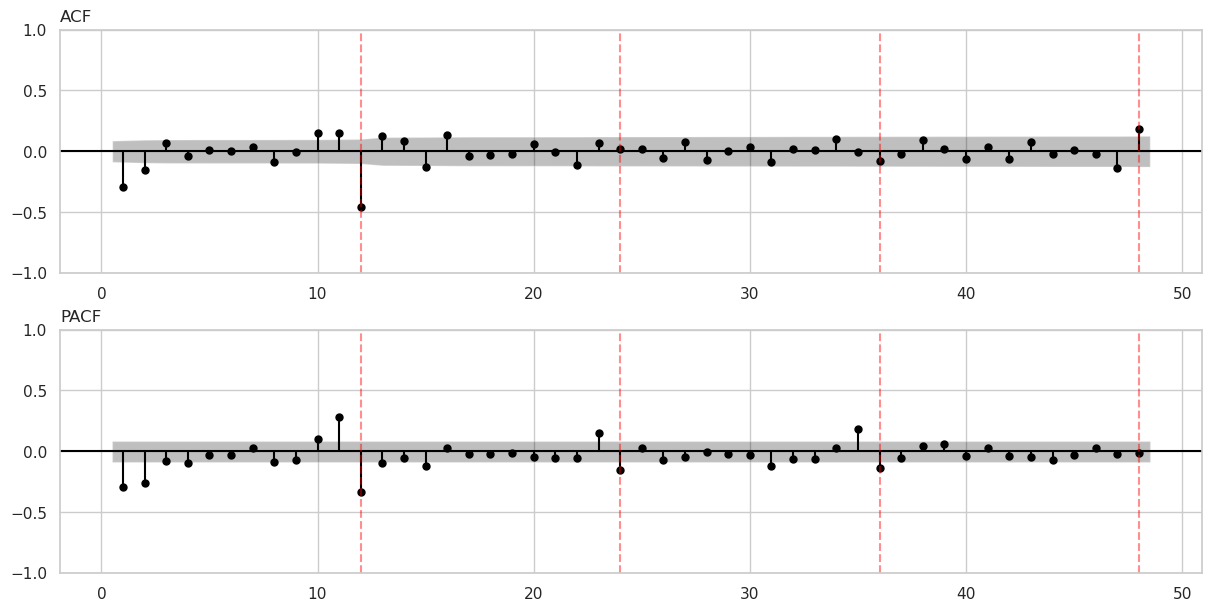

In [157]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
xcoords = [i * sp for i in range(1, 5)]

sm.graphics.tsa.plot_acf(y_nx_train_EDA['y'].dropna(), ax=ax[0], lags=4 * sp, zero=False, title='ACF')
for xc in xcoords:
    ax[0].axvline(x=xc, color='red', linestyle='--', alpha=0.25)
    ax[0].axvline(x=xc, color='red', linestyle='--', alpha=0.25)
sm.graphics.tsa.plot_pacf(y_nx_train_EDA['y'].dropna(), ax=ax[1], lags=4 * sp, zero=False, title='PACF')
for xc in xcoords:
    ax[1].axvline(x=xc, color='red', linestyle='--', alpha=0.25)
    ax[1].axvline(x=xc, color='red', linestyle='--', alpha=0.25)
plt.show();plt.close()


As a result we propose the following $(P, Q)$ order for the seasonal component of the model:

In [158]:
P = 0
Q = 1

#### Regular Component

To identify the regular component of the model we use again  the ACF and PACF of the differenced time series but this time  **we focus on the first values of the ACF and PACF before the seasonal frequency**. This is illustrated by the shaded area in the ACF and PACF below. 

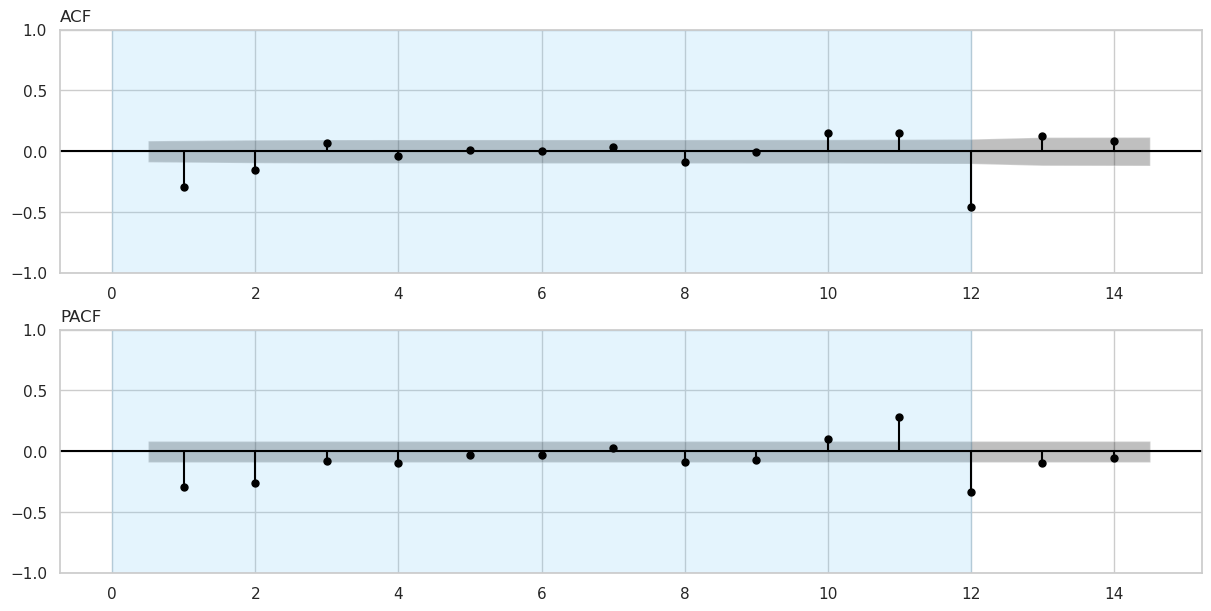

In [159]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

sm.graphics.tsa.plot_acf(y_nx_train_EDA['y'].dropna(), ax=ax[0], lags= 1.2 * sp , zero=False, title='ACF')
ax[0].axvspan(0, sp, color='#7BC8F6', alpha=0.2)

sm.graphics.tsa.plot_pacf(y_nx_train_EDA['y'].dropna(), ax=ax[1], lags= 1.2 * sp, zero=False, title='PACF')
ax[1].axvspan(0, sp, color='#7BC8F6', alpha=0.2)

plt.show();plt.close()


The pattern in these values suggests that  AR and MA may both be present. So  we can try an initial guess such as the following:

In [160]:
p = 1
q = 1

### Check the SARIMA structure

In [161]:
if use_boxcox:
    print(f"Fitting a SARIMA model on Box-Cox transformed data with lambda = {y_train_lambda:.4f}")
else:
    print("Fitting ARIMA model on original data without Box-Cox transformation.")
print("And this structure: ")
print(f"(p, d, q)=({p}, {d}, {q}), (P, D, Q, sp)=({P}, {D}, {Q}, {sp})")

Fitting ARIMA model on original data without Box-Cox transformation.
And this structure: 
(p, d, q)=(1, 1, 1), (P, D, Q, sp)=(0, 1, 1, 12)


## Defining and fitting the Nixtla seasonal SARIMA model (and other models for comparison)

Now we define the model. We will also include a seasonal naive model and the MSTL model for comparison:

In [162]:
if (d + D > 0):
    print("Including a constant term in the ARIMA model to account for differencing.")
    include_constant = True


models = [ARIMA(order=(p, d, q), seasonal_order=(P, D, Q), 
                alias='arima_seas', season_length=sp, include_constant=include_constant), 
                SeasonalNaive(alias='naive_seas', season_length=sp),
                MSTL(alias='mstl_seas', season_length=sp)]

y_seas_models = StatsForecast(models=models, freq="MS", n_jobs=-1)

Including a constant term in the ARIMA model to account for differencing.


We fit the models:

In [163]:
y_seas_models.fit(y_nx_train)

StatsForecast(models=[arima_seas,naive_seas,mstl_seas])

### Model diagnostics (SARIMA with Nixtla )

We need to obtain the residuals of the SARIMA model

In [164]:
y_seas_models.forecast(df=y_nx_train, h=fh, fitted=True)
fitted = y_seas_models.forecast_fitted_values()['arima_seas']
residuals  = y_nx_train['y'] - fitted
residuals


0      8.260e-04
1      2.728e-04
2      2.600e-04
3     -1.110e-05
4     -5.752e-05
         ...    
513   -1.606e-01
514    1.811e-01
515    1.715e-01
516   -1.568e-01
517   -1.487e-01
Length: 518, dtype: float64

And now we can use the auxiliary function to check for significance:

In [165]:
nixtla_summary_table(y_seas_models, unique_id='y', residuals=residuals, model_idx=0)

                             Nixtla Summary Results                             


,Model,Log Likelihood,AIC,BIC,Sigma2
0,"ARIMA(1,1,1)(0,1,1)[12]",-82.374,172.747,189.646,0.08080


--------------------------------------------------------------------------------


,coef,std err,z,P > |z|,[0.025,0.975]
ar1,0.449,0.04,11.340,0.0,0.371,0.527
ma1,-0.761,0.04,-19.210,0.0,-0.839,-0.683
sma1,-0.573,0.04,-14.471,0.0,-0.651,-0.496


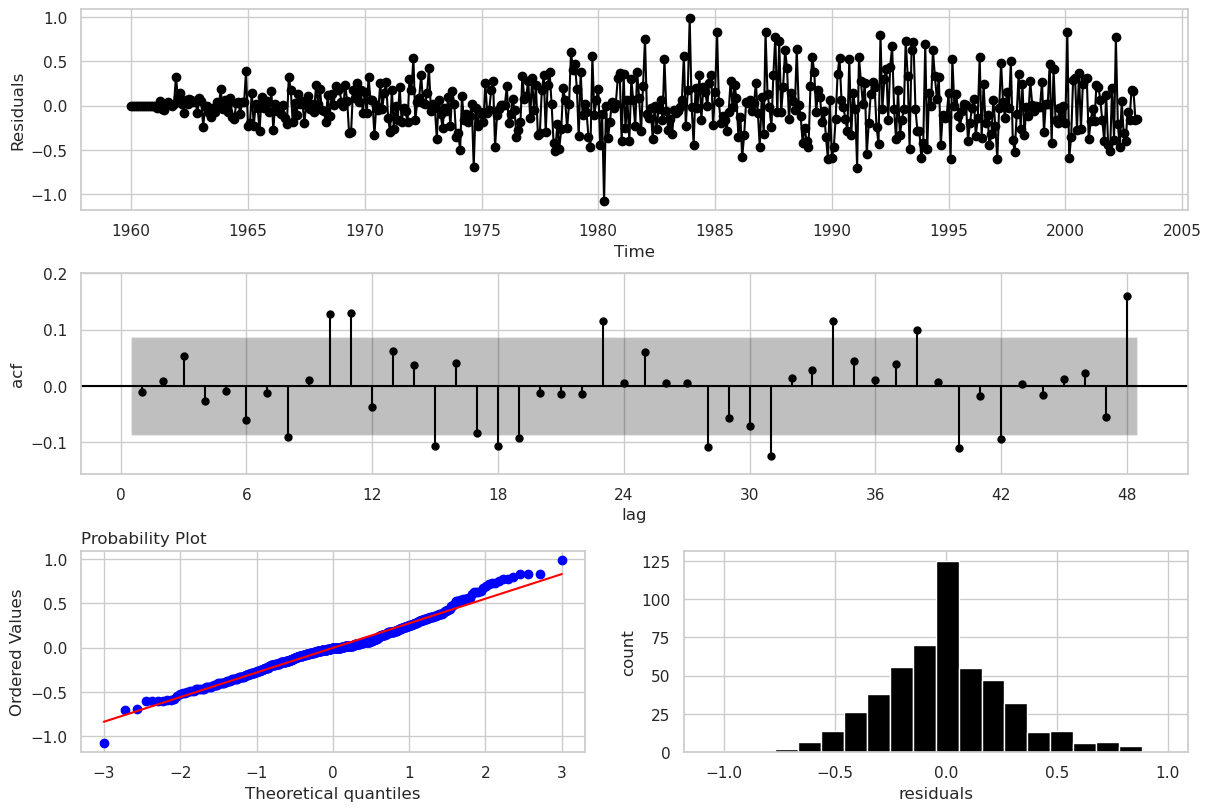

In [166]:
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "acf"] , ["qq", "hist"]], figsize=(12, 8))
axes["resid"].plot(y_nx_train["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Time", ylabel="Residuals")
axes["qq"].set_title("QQ Plot")
stats.probplot(residuals, dist="norm", plot=axes["qq"])
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True, lags=4 * sp,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

As in the statsmodels case, the residuals are not perfectly white noise, but they are good enough for the case of a real dataset.

In [167]:
sm.stats.acorr_ljungbox(residuals, np.arange(1, 2 * sp, 1))

,lb_stat,lb_pvalue
1,0.068,7.937e-01
2,0.109,9.467e-01
3,1.583,6.631e-01
4,1.956,7.439e-01
5,1.997,8.495e-01
6,3.953,6.830e-01
7,4.042,7.749e-01
8,8.326,4.023e-01
9,8.380,4.964e-01
10,16.941,7.568e-02


### Visualizing the predictions

In [168]:
y_seas_models_pred = y_seas_models.predict(h=fh)
y_seas_models_pred.head(min(10, fh))

,unique_id,ds,arima_seas,naive_seas,mstl_seas
0,y,2003-03-01,18.809,19.288,18.691
1,y,2003-04-01,18.007,18.237,18.033
2,y,2003-05-01,18.295,18.240,18.288
3,y,2003-06-01,17.460,17.508,17.356
4,y,2003-07-01,18.203,18.096,18.173
5,y,2003-08-01,18.063,17.793,18.112
6,y,2003-09-01,17.378,17.166,17.533
7,y,2003-10-01,18.357,18.112,18.426
8,y,2003-11-01,18.221,18.135,18.264
9,y,2003-12-01,19.125,19.130,19.169


In [169]:
plot_df = y_nx_test.set_index('ds')[['y']].copy()

if use_boxcox:
    plot_df['y'] = boxcox(plot_df['y'], lmbda=y_train_lambda)

plot_df.head()


,y
ds,
2003-03-01,18.413
2003-04-01,17.447
2003-05-01,17.560
2003-06-01,16.848
2003-07-01,17.384


#### Visualizing predicted vs real

In [170]:
y_seas_models_preds = y_seas_models.predict(h=fh)
y_seas_models_preds.head(min(10, fh))

,unique_id,ds,arima_seas,naive_seas,mstl_seas
0,y,2003-03-01,18.809,19.288,18.691
1,y,2003-04-01,18.007,18.237,18.033
2,y,2003-05-01,18.295,18.240,18.288
3,y,2003-06-01,17.460,17.508,17.356
4,y,2003-07-01,18.203,18.096,18.173
5,y,2003-08-01,18.063,17.793,18.112
6,y,2003-09-01,17.378,17.166,17.533
7,y,2003-10-01,18.357,18.112,18.426
8,y,2003-11-01,18.221,18.135,18.264
9,y,2003-12-01,19.125,19.130,19.169


In the following plot we have included the predictions from both statsmodels and Nixtla, so that we can visually check that they agree.

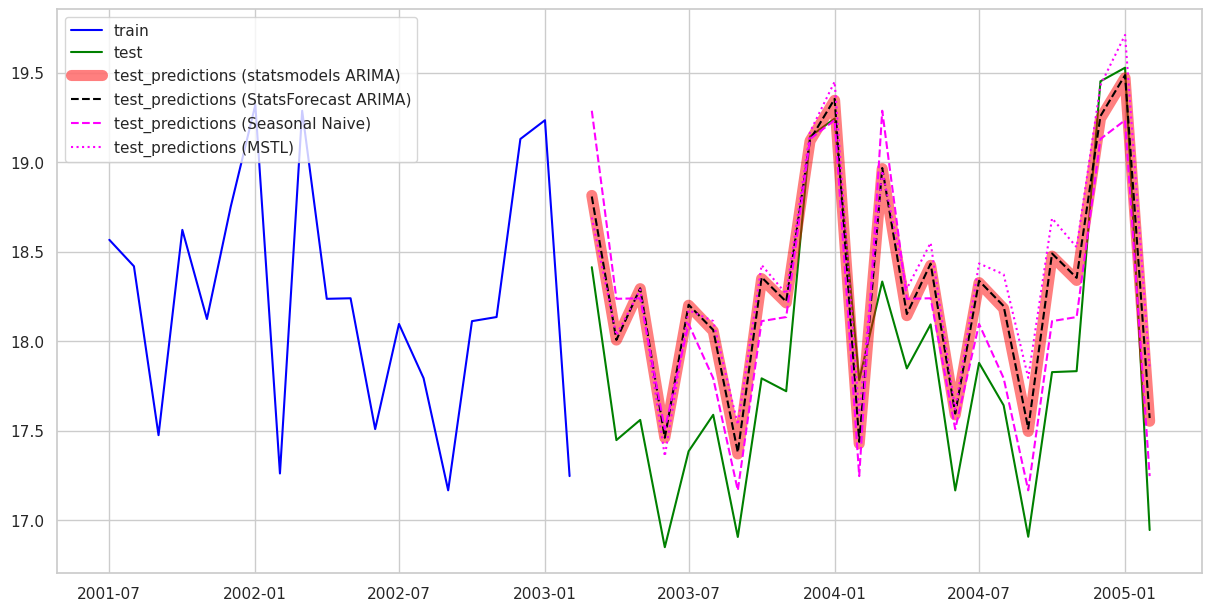

In [171]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(y_nx_train.set_index('ds')['y'].tail(20), label='train', color='blue')
ax.plot(plot_df['y'], label='test', color='green')

ax.plot(arima_model.predict(start=y_nx_test.index[0], end=y_nx_test.index[-1]), label='SARIMA statsmodels', color = "red", alpha=0.5, linewidth=8)

ax.plot(y_seas_models_preds.set_index('ds')[['arima_seas']], label='test predictions', color='black', linestyle='--')
ax.plot(y_seas_models_preds.set_index('ds')[['naive_seas']], label='seasonal naive predictions', color='magenta', linestyle='--')
ax.plot(y_seas_models_preds.set_index('ds')[['mstl_seas']], 
        label='MSTL predictions', color='magenta', linestyle=':')

ax.legend(["train", "test", "test_predictions (statsmodels ARIMA)",
           "test_predictions (StatsForecast ARIMA)", "test_predictions (Seasonal Naive)", "test_predictions (MSTL)"])
plt.show();plt.close()

# Forecasting performance of ARIMA models

::: {.callout-note  icon=false}

#### Cross validation scores with ARIMA Models

The major difference between the two libraries is in the prediction step. We will see that in this case the `Nixtla Statsforecast` implementation is much easier to use.

We will use temporal cross validation to evaluate the model. The way we do this is with the `ExpandingWindowSplitter`, that we already met with the naive models. We will use a forecasting horizon of length 1 (one-step-ahead forecasting). We will keep the first half of the training set as initial window, to ensure that the model has enough data to make the first forecast.

:::

In [172]:
y_cv_df = y_seas_models.cross_validation(
    df = y_nx_train,
    h = fh,
    step_size = 1,
    n_windows = 10)

In [173]:
y_cv_df.head()

,unique_id,ds,cutoff,y,arima_seas,naive_seas,mstl_seas
0,y,2000-06-01,2000-05-01,17.031,16.708,16.241,16.765
1,y,2000-07-01,2000-05-01,17.676,17.738,17.545,17.560
2,y,2000-08-01,2000-05-01,17.980,17.628,17.293,17.568
3,y,2000-09-01,2000-05-01,17.207,17.210,16.771,17.147
4,y,2000-10-01,2000-05-01,18.265,17.979,17.567,18.004


In [174]:
model_list = [_.alias for _ in y_seas_models.models]
model_list

['arima_seas', 'naive_seas', 'mstl_seas']

In [175]:
from utilsforecast.evaluation import evaluate
y_seas_eval = evaluate(y_cv_df, metrics=[rmse, mape], models=model_list)
y_seas_eval

,unique_id,cutoff,metric,arima_seas,naive_seas,mstl_seas
0,y,2000-05-01,rmse,0.345,0.824,0.348
1,y,2000-06-01,rmse,0.344,0.768,0.377
2,y,2000-07-01,rmse,0.346,0.766,0.381
3,y,2000-08-01,rmse,0.449,0.724,0.527
4,y,2000-09-01,rmse,0.437,0.706,0.503
5,y,2000-10-01,rmse,0.544,0.661,0.603
6,y,2000-11-01,rmse,0.709,0.610,0.752
7,y,2000-12-01,rmse,0.908,0.572,0.969
8,y,2001-01-01,rmse,0.756,0.529,0.819
9,y,2001-02-01,rmse,0.728,0.532,0.784


In [176]:
y_seas_eval.groupby("metric")[model_list].mean()

,arima_seas,naive_seas,mstl_seas
metric,,,
mape,0.025,0.032,0.028
rmse,0.557,0.669,0.606


## Test set evaluation for the Nixtla SARIMA model

Analogous to the non seasonal case.

In [177]:
y_cv_df_test = y_seas_models.cross_validation(
    df = pd.concat([y_nx_train, y_nx_test]),
    h = fh,
    step_size = 1,
    n_windows = 1)

In [178]:
y_seas_test_eval = evaluate(y_cv_df_test, metrics=[rmse, mape], models=model_list)
y_seas_test_eval

,unique_id,cutoff,metric,arima_seas,naive_seas,mstl_seas
0,y,2003-02-01,rmse,0.501,0.468,0.576
1,y,2003-02-01,mape,0.026,0.022,0.030


::: {.callout-note  icon=false}

## In the Next Sessions

Our plan for the next session is to add additional time series as exogenous predictors (SARIMAX models). We will also discuss *autoarima* strategies. And finally we will see how to use Machine Learning models such as boosting models for forecasting.

:::

# References